# ABDA Notebook

Bayesian predictive models for public transport delays, implemented locally for VS Code / Jupyter.

Implemented models:
- Model A: single Student-t regression on `y = log1p(delay_minutes)`
- Model B: 2-component Student-t mixture regression
- Model C: hurdle (zero/positive) lognormal regression
- Model D: hierarchical Student-t regression with route-level partial pooling


## Local setup

Install dependencies in your terminal before running the notebook:

```powershell
pip install cmdstanpy arviz kagglehub[pandas-datasets] pandas numpy matplotlib scipy
python -m cmdstanpy.install_cmdstan
```

A working installation of CmdStan is assumed to be available.

In [1]:
import math
import os
from collections import Counter
from pathlib import Path

import arviz as az
from cmdstanpy import CmdStanModel
from IPython.display import display
import kagglehub
from kagglehub import KaggleDatasetAdapter
import matplotlib.pyplot as plt
from matplotlib.ticker import PercentFormatter
import numpy as np
import pandas as pd
import xarray as xr
from scipy.stats import gaussian_kde

RANDOM_SEED = 42
rng = np.random.default_rng(RANDOM_SEED)
az.rcParams["stats.ci_prob"] = 0.95

plt.rcParams.update(
    {
        "figure.figsize": (8, 4.8),
        "figure.facecolor": "#f6f1e8",
        "axes.facecolor": "#fcfaf5",
        "axes.spines.top": False,
        "axes.spines.right": False,
        "axes.grid": True,
        "grid.alpha": 0.15,
        "grid.linewidth": 0.8,
        "axes.titlesize": 14,
        "axes.titleweight": "bold",
        "axes.labelsize": 11,
        "legend.frameon": False,
        "font.size": 11,
    }
)


c:\Users\dell\anaconda3\Lib\site-packages\arviz\__init__.py:39: FutureWarning: 
ArviZ is undergoing a major refactor to improve flexibility and extensibility while maintaining a user-friendly interface.
Some upcoming changes may be backward incompatible.
For details and migration guidance, visit: https://python.arviz.org/en/latest/user_guide/migration_guide.html
  warn(


## Step 1  Load data locally

Set `LOCAL_CSV_PATH` if you already have the CSV on disk. Leave it as `None` to load through KaggleHub.


In [ ]:
LOCAL_CSV_PATH = None 
DATASET = "khushikyad001/public-transport-delays-with-weather-and-events"

if LOCAL_CSV_PATH is not None:
    df = pd.read_csv(LOCAL_CSV_PATH)
    print("Using local CSV:", LOCAL_CSV_PATH)
else:
    ds_path = Path(kagglehub.dataset_download(DATASET))
    print("Downloaded to:", ds_path)

    csv_files = sorted([p.name for p in ds_path.iterdir() if p.suffix.lower() == ".csv"])
    if not csv_files:
        raise FileNotFoundError(f"No CSV file found under {ds_path}")

    file_name = csv_files[0]
    print("Files:", csv_files)
    print("Using CSV:", file_name)

    df = kagglehub.dataset_load(
        KaggleDatasetAdapter.PANDAS,
        DATASET,
        file_name,
    )

print("Shape:", df.shape)
print("Columns:", df.columns.tolist())
df.head()


Downloaded to: C:\Users\dell\.cache\kagglehub\datasets\khushikyad001\public-transport-delays-with-weather-and-events\versions\1
Files: ['public_transport_delays.csv']
Using CSV: public_transport_delays.csv
Shape: (2000, 24)
Columns: ['trip_id', 'date', 'time', 'transport_type', 'route_id', 'origin_station', 'destination_station', 'scheduled_departure', 'scheduled_arrival', 'actual_departure_delay_min', 'actual_arrival_delay_min', 'weather_condition', 'temperature_C', 'humidity_percent', 'wind_speed_kmh', 'precipitation_mm', 'event_type', 'event_attendance_est', 'traffic_congestion_index', 'holiday', 'peak_hour', 'weekday', 'season', 'delayed']


,trip_id,date,time,transport_type,route_id,origin_station,destination_station,scheduled_departure,scheduled_arrival,actual_departure_delay_min,...,wind_speed_kmh,precipitation_mm,event_type,event_attendance_est,traffic_congestion_index,holiday,peak_hour,weekday,season,delayed
0,T00000,2023-01-01,05:00:00,Tram,Route_15,Station_31,Station_6,05:02:00,05:55:00,12,...,46,13.0,NaN,500,81,0,1,6,Winter,0
1,T00001,2023-01-01,05:15:00,Metro,Route_12,Station_49,Station_32,05:16:00,05:55:00,15,...,11,11.4,NaN,0,53,0,0,6,Autumn,1
2,T00002,2023-01-01,05:30:00,Bus,Route_16,Station_29,Station_42,05:33:00,06:17:00,0,...,31,14.1,Sports,0,67,1,0,6,Autumn,0
3,T00003,2023-01-01,05:45:00,Tram,Route_19,Station_26,Station_18,05:49:00,06:08:00,15,...,41,6.4,NaN,500,84,0,0,6,Winter,1
4,T00004,2023-01-01,06:00:00,Tram,Route_8,Station_18,Station_15,06:00:00,06:35:00,-1,...,30,18.5,NaN,500,46,0,0,6,Spring,1


## Step 2: Preparing the target and design matrix

The response variable is `delay_minutes ≥ 0`, which is transformed as `y = log1p(delay_minutes)`.
Covariates include weather, event indicators, transport type, route, origin station, destination station, weekday, season, and time-of-day features.

In Model D, route is treated as a varying intercept instead of a fixed-effect dummy block. The fixed-effect matrix for Model D therefore excludes route one-hot columns, while Models A/B/C keep the original design matrix.

In [3]:
DELAY_CAP = 300
delay_candidates = [
    "actual_departure_delay_min",
    "departure_delay_min",
    "delay_min",
    "delay_minutes",
    "Delay_Minutes",
    "Delay",
]
delay_col = next((c for c in delay_candidates if c in df.columns), None)
if delay_col is None:
    raise KeyError(f"Could not find a delay column. Available columns: {df.columns.tolist()}")

model_df = df.copy()
delay_raw = pd.to_numeric(model_df[delay_col], errors="coerce")
delay_raw = delay_raw.replace([np.inf, -np.inf], np.nan)
model_df["delay_minutes"] = delay_raw.clip(lower=0, upper=DELAY_CAP)

model_df["transport_type"] = model_df["transport_type"].fillna("Unknown").astype(str)
model_df["route_id"] = model_df["route_id"].fillna("Unknown").astype(str)
model_df["origin_station"] = model_df["origin_station"].fillna("Unknown").astype(str)
model_df["destination_station"] = model_df["destination_station"].fillna("Unknown").astype(str)
model_df["weather_condition"] = model_df["weather_condition"].fillna("Unknown").astype(str)
model_df["season"] = model_df["season"].fillna("Unknown").astype(str)
model_df["event_type"] = model_df["event_type"].fillna("None").astype(str).replace("nan", "None")
model_df["weekday"] = model_df["weekday"].astype(str)

time_source = model_df["scheduled_departure"].fillna(model_df["time"])
clock = pd.to_datetime(time_source, format="%H:%M:%S", errors="coerce")
model_df["hour_float"] = clock.dt.hour + clock.dt.minute / 60.0
model_df["hour_sin"] = np.sin(2 * np.pi * model_df["hour_float"] / 24.0)
model_df["hour_cos"] = np.cos(2 * np.pi * model_df["hour_float"] / 24.0)
model_df["has_event"] = (model_df["event_type"] != "None").astype(int)

scaled_numeric_cols = [
    "temperature_C",
    "precipitation_mm",
    "wind_speed_kmh",
    "humidity_percent",
    "event_attendance_est",
    "traffic_congestion_index",
]
binary_cols = ["holiday", "peak_hour", "has_event"]
cyclic_cols = ["hour_sin", "hour_cos"]
categorical_cols = [
    "transport_type",
    "weather_condition",
    "season",
    "weekday",
    "route_id",
    "origin_station",
    "destination_station",
]

analysis_cols = ["delay_minutes", "hour_float"] + scaled_numeric_cols + binary_cols + cyclic_cols + categorical_cols
analysis_df = model_df[analysis_cols].dropna().reset_index(drop=True)
analysis_df["y"] = np.log1p(analysis_df["delay_minutes"])

def zscore(series: pd.Series) -> pd.Series:
    values = pd.to_numeric(series, errors="coerce").astype(float)
    sd = values.std(ddof=0)
    if not np.isfinite(sd) or sd == 0:
        return pd.Series(np.zeros(len(values)), index=series.index)
    return (values - values.mean()) / sd

for col in scaled_numeric_cols:
    analysis_df[col] = zscore(analysis_df[col])

for col in binary_cols:
    analysis_df[col] = analysis_df[col].astype(int)

X_numeric = analysis_df[scaled_numeric_cols + binary_cols + cyclic_cols].astype(float)
X_categorical = pd.get_dummies(
    analysis_df[categorical_cols],
    drop_first=True,
    dtype=float,
)
X_df = pd.concat([X_numeric, X_categorical], axis=1)

feature_names = X_df.columns.tolist()
X = X_df.to_numpy(dtype=float)

route_levels = sorted(analysis_df["route_id"].unique().tolist())
route_lookup = {route_name: idx + 1 for idx, route_name in enumerate(route_levels)}
route_idx = analysis_df["route_id"].map(route_lookup).to_numpy(dtype=int)
J_route = len(route_levels)

route_dummy_cols = [col for col in X_df.columns if col.startswith("route_id_")]
X_hier_df = X_df.drop(columns=route_dummy_cols)
feature_names_hier = X_hier_df.columns.tolist()
X_hier = X_hier_df.to_numpy(dtype=float)

delay = analysis_df["delay_minutes"].to_numpy(dtype=float)
y = analysis_df["y"].to_numpy(dtype=float)
z = (delay > 0).astype(int)

N, K = X.shape
_, K_hier = X_hier.shape
y_bar = float(y.mean())
positive_rate = float(z.mean())
logit_positive_rate = float(np.log(positive_rate / (1 - positive_rate)))
log_delay_pos_mean = float(np.log(delay[delay > 0]).mean())

print("Using delay column:", delay_col)
print("N:", N, "K:", K, "K_hier:", K_hier, "J_route:", J_route)
print("Observed zero proportion:", float(np.mean(delay == 0)))
print(pd.Series(delay).describe())


Using delay column: actual_departure_delay_min
N: 2000 K: 145 K_hier: 126 J_route: 20
Observed zero proportion: 0.1235
count    2000.000000
mean        8.807500
std         6.082347
min         0.000000
25%         3.000000
50%         9.000000
75%        14.000000
max        19.000000
dtype: float64


## Step 3 : Dataset snapshot and quick EDA


,value
observations,2000.0000
predictors_model_abc,145.0000
predictors_model_d,126.0000
unique_routes,20.0000
observed_zero_share,0.1235
max_delay_minutes,19.0000
delay_q95,18.0000
delay_q99,19.0000


,feature_count_model_abc
destination,49
origin,49
route,19
weekday,6
weather,5
season,3
transport,3
hour,2
temperature,1
has,1


,feature_count_model_d
destination,49
origin,49
weekday,6
weather,5
season,3
transport,3
hour,2
temperature,1
peak,1
holiday,1


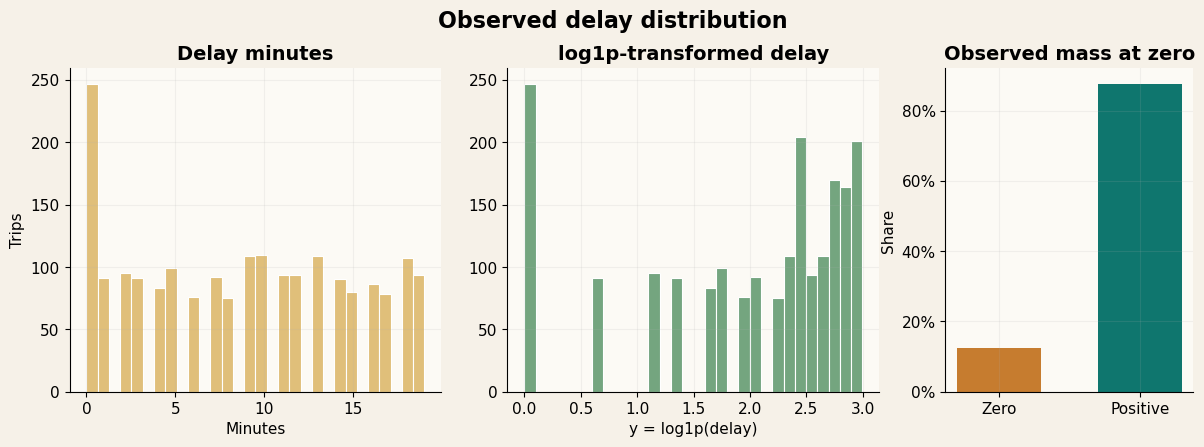

In [4]:
feature_group_counts = pd.Series(Counter(name.split("_")[0] for name in feature_names)).sort_values(ascending=False)
hier_feature_group_counts = pd.Series(Counter(name.split("_")[0] for name in feature_names_hier)).sort_values(ascending=False)

summary_table = pd.DataFrame(
    {
        "value": [
            N,
            K,
            K_hier,
            J_route,
            float(np.mean(delay == 0)),
            float(delay.max()),
            float(np.quantile(delay, 0.95)),
            float(np.quantile(delay, 0.99)),
        ]
    },
    index=[
        "observations",
        "predictors_model_abc",
        "predictors_model_d",
        "unique_routes",
        "observed_zero_share",
        "max_delay_minutes",
        "delay_q95",
        "delay_q99",
    ],
)
display(summary_table)
display(feature_group_counts.to_frame("feature_count_model_abc"))
display(hier_feature_group_counts.to_frame("feature_count_model_d"))

fig, axes = plt.subplots(1, 3, figsize=(14.5, 4.2), gridspec_kw={"width_ratios": [1.2, 1.2, 0.8]})

axes[0].hist(delay, bins=30, color="#e0bf7a", edgecolor="white", linewidth=0.8)
axes[0].set_title("Delay minutes")
axes[0].set_xlabel("Minutes")
axes[0].set_ylabel("Trips")

axes[1].hist(y, bins=30, color="#74a57f", edgecolor="white", linewidth=0.8)
axes[1].set_title("log1p-transformed delay")
axes[1].set_xlabel("y = log1p(delay)")

zero_share = np.mean(delay == 0)
axes[2].bar(["Zero", "Positive"], [zero_share, 1 - zero_share], color=["#c67c2f", "#0f766e"], width=0.6)
axes[2].yaxis.set_major_formatter(PercentFormatter(1.0))
axes[2].set_title("Observed mass at zero")
axes[2].set_ylabel("Share")

fig.suptitle("Observed delay distribution", fontsize=16, fontweight="bold", y=1.02)
plt.show()


## Step 4 : Helper utilities


In [5]:
STAN_DIR = Path("stan_models")
STAN_DIR.mkdir(exist_ok=True)

SAMPLE_ARGS = dict(
    chains=4,
    parallel_chains=4,
    iter_warmup=1000,
    iter_sampling=1000,
    seed=RANDOM_SEED,
    adapt_delta=0.99,
    max_treedepth=15,
)


FORCE_RECOMPILE = False

def load_cmdstan_model(stan_path: Path, force_recompile: bool = FORCE_RECOMPILE) -> CmdStanModel:
    exe_path = stan_path.with_suffix(".exe")
    if exe_path.exists() and not force_recompile:
        print(f"Using existing executable: {exe_path.name} (set FORCE_RECOMPILE=True to rebuild)")
        return CmdStanModel(stan_file=str(stan_path), exe_file=str(exe_path), compile=False)
    return CmdStanModel(stan_file=str(stan_path))

def write_stan_file(file_name: str, stan_code: str) -> Path:
    path = STAN_DIR / file_name
    stan_text = stan_code.rstrip() + "\n"
    if (not path.exists()) or (path.read_text(encoding="utf-8") != stan_text):
        path.write_text(stan_text, encoding="utf-8")
    return path

def reshape_draws(fit, var_name: str) -> np.ndarray:
    draws = fit.stan_variable(var_name)
    return draws.reshape(fit.chains, -1, draws.shape[-1])

def make_idata(
    fit,
    observed_y: np.ndarray,
    feature_vars=None,
    feature_names_override=None,
    feature_coord_name: str = "feature",
    extra_coords=None,
    extra_dims=None,
):
    coords = {"obs_id": np.arange(len(observed_y))}
    dims = {"y": ["obs_id"], "log_lik": ["obs_id"]}

    if feature_vars:
        coords[feature_coord_name] = feature_names if feature_names_override is None else feature_names_override
        for var_name in feature_vars:
            dims[var_name] = [feature_coord_name]

    if extra_coords:
        coords.update(extra_coords)
    if extra_dims:
        dims.update(extra_dims)

    idata = az.from_cmdstanpy(
        posterior=fit,
        log_likelihood="log_lik",
        observed_data={"y": observed_y},
        coords=coords,
        dims=dims,
    )
    idata.add_groups({"posterior_predictive": {"y_rep": reshape_draws(fit, "y_rep")}})
    return idata

def adjust_loglik_to_delay_scale(idata, observed_y: np.ndarray):
    observed = xr.DataArray(observed_y, dims=["obs_id"], coords={"obs_id": np.arange(len(observed_y))})
    loglik_name = next(iter(idata.log_likelihood.data_vars))
    idata.log_likelihood[loglik_name] = idata.log_likelihood[loglik_name] - observed
    return idata

def select_summary_columns(summary_df: pd.DataFrame) -> pd.DataFrame:
    interval_cols = [col for col in summary_df.columns if col.startswith(("hdi_", "eti_"))]
    core_cols = ["mean", "sd"] + interval_cols[:2] + ["r_hat", "ess_bulk"]
    available = [col for col in core_cols if col in summary_df.columns]
    return summary_df[available]

def posterior_coef_summary(fit, var_name: str, names, top_n: int = 12) -> pd.DataFrame:
    draws = fit.stan_variable(var_name)
    q05, q50, q95 = np.quantile(draws, [0.05, 0.50, 0.95], axis=0)
    mean = draws.mean(axis=0)
    out = pd.DataFrame(
        {
            "feature": names,
            "mean": mean,
            "median": q50,
            "q05": q05,
            "q95": q95,
        }
    )
    return out.iloc[np.argsort(np.abs(out["mean"].to_numpy()))[::-1]].head(top_n).reset_index(drop=True)

def varying_effect_summary(fit, var_name: str, names, top_n: int = 8) -> pd.DataFrame:
    draws = fit.stan_variable(var_name)
    q05, q50, q95 = np.quantile(draws, [0.05, 0.50, 0.95], axis=0)
    mean = draws.mean(axis=0)
    out = pd.DataFrame(
        {
            "group": names,
            "mean": mean,
            "median": q50,
            "q05": q05,
            "q95": q95,
        }
    )
    return out.iloc[np.argsort(np.abs(out["mean"].to_numpy()))[::-1]].head(top_n).reset_index(drop=True)

def divergence_count(fit) -> int:
    try:
        return int(np.sum(fit.method_variables()["divergent__"]))
    except Exception:
        return 0

def positive_density_band(delay_rep: np.ndarray, obs_delay: np.ndarray, lower=0.10, upper=0.90, max_draws=250, x_q=0.99):
    pos_obs = obs_delay[obs_delay > 0]
    xmax = np.quantile(pos_obs, x_q)
    x = np.linspace(0, xmax, 450)

    draw_idx = rng.choice(delay_rep.shape[0], size=min(max_draws, delay_rep.shape[0]), replace=False)
    dens = []
    for idx in draw_idx:
        pr = delay_rep[idx]
        pr = pr[pr > 0]
        if len(pr) > 5:
            dens.append(gaussian_kde(pr)(x))

    dens = np.vstack(dens)
    return x, pos_obs, np.median(dens, axis=0), np.quantile(dens, lower, axis=0), np.quantile(dens, upper, axis=0)

def plot_delay_ppc(idata, title: str, zero_mode: str = "approx"):
    y_rep = np.asarray(idata.posterior_predictive["y_rep"]).reshape(-1, len(delay))
    raw_delay_rep = np.expm1(y_rep)
    delay_rep = np.maximum(raw_delay_rep, 0.0)

    if zero_mode == "exact":
        pred_zero_share = np.mean(np.isclose(y_rep, 0.0), axis=1)
        zero_caption = "Exact zero share"
    else:
        pred_zero_share = np.mean(raw_delay_rep < 0.5, axis=1)
        zero_caption = "Share below 0.5 min"

    obs_zero_share = np.mean(delay == 0)
    zero_q10, zero_q90 = np.quantile(pred_zero_share, [0.10, 0.90])
    x, pos_obs, d_med, d_lo, d_hi = positive_density_band(delay_rep, delay)

    fig = plt.figure(figsize=(13, 5.5), facecolor="#f6f1e8")
    gs = fig.add_gridspec(1, 2, width_ratios=[1.0, 2.4], wspace=0.22)
    ax0 = fig.add_subplot(gs[0, 0], facecolor="#fcfaf5")
    ax1 = fig.add_subplot(gs[0, 1], facecolor="#fcfaf5")

    obs_color = "#c67c2f"
    pred_color = "#0f766e"
    band_color = "#6bb8a9"
    hist_color = "#e9d7aa"

    bars = ax0.bar(
        ["Observed", "Predictive"],
        [obs_zero_share, pred_zero_share.mean()],
        color=[obs_color, pred_color],
        width=0.62,
        edgecolor="none",
    )
    ax0.errorbar(
        1,
        pred_zero_share.mean(),
        yerr=[[pred_zero_share.mean() - zero_q10], [zero_q90 - pred_zero_share.mean()]],
        fmt="none",
        ecolor="#184e47",
        elinewidth=2,
        capsize=6,
    )
    ax0.yaxis.set_major_formatter(PercentFormatter(1.0))
    ax0.set_ylim(0, max(obs_zero_share, zero_q90) * 1.28)
    ax0.set_title("Zero-mass fit", fontsize=13, fontweight="bold")
    ax0.set_ylabel(zero_caption)
    for bar, val in zip(bars, [obs_zero_share, pred_zero_share.mean()]):
        ax0.text(bar.get_x() + bar.get_width() / 2, val + 0.01, f"{val:.1%}", ha="center", va="bottom", fontsize=11)
    ax0.text(
        1,
        zero_q90 + 0.015,
        f"80% interval\n{zero_q10:.1%} - {zero_q90:.1%}",
        ha="center",
        va="bottom",
        fontsize=9,
        color="#184e47",
    )

    ax1.hist(
        pos_obs,
        bins=28,
        density=True,
        color=hist_color,
        edgecolor="white",
        linewidth=0.8,
        alpha=0.95,
        label="Observed positive delays",
    )
    ax1.fill_between(x, d_lo, d_hi, color=band_color, alpha=0.28, label="80% predictive band")
    ax1.plot(x, d_med, color=pred_color, linewidth=2.6, label="Median predictive density")
    ax1.set_xlim(0, x.max())
    ax1.set_xlabel("Delay (minutes)")
    ax1.set_ylabel("Density")
    ax1.set_title("Positive-delay fit", fontsize=13, fontweight="bold")
    ax1.legend(loc="upper right")

    fig.suptitle(title, fontsize=16, fontweight="bold", y=0.98)
    plt.show()

def plot_delay_ppc_kde(idata, title: str, lower=0.10, upper=0.90, max_draws=250, x_q=0.995):
    y_obs = np.asarray(idata.observed_data["y"]).ravel()
    y_rep = np.asarray(idata.posterior_predictive["y_rep"]).reshape(-1, len(y_obs))

    x_max = float(np.quantile(np.concatenate([y_obs, y_rep.reshape(-1)]), x_q))
    x = np.linspace(0, x_max, 500)

    sample_idx = rng.choice(y_rep.shape[0], size=min(max_draws, y_rep.shape[0]), replace=False)
    dens = []
    for idx in sample_idx:
        draw = y_rep[idx]
        if np.std(draw) > 1e-8:
            dens.append(gaussian_kde(draw)(x))

    dens = np.vstack(dens)
    obs_kde = gaussian_kde(y_obs)(x)
    d_med = np.median(dens, axis=0)
    d_lo = np.quantile(dens, lower, axis=0)
    d_hi = np.quantile(dens, upper, axis=0)

    fig, ax = plt.subplots(figsize=(9.5, 5.0), facecolor="#f6f1e8")
    ax.set_facecolor("#fcfaf5")

    ax.hist(
        y_obs,
        bins=28,
        density=True,
        color="#ead39c",
        edgecolor="white",
        linewidth=0.7,
        alpha=0.65,
        label="Observed y histogram",
    )
    ax.fill_between(x, d_lo, d_hi, color="#6bb8a9", alpha=0.28, label="80% predictive KDE band")
    ax.plot(x, d_med, color="#0f766e", linewidth=2.5, label="Median predictive KDE")
    ax.plot(x, obs_kde, color="#9a3412", linewidth=2.2, linestyle="--", label="Observed KDE")

    ax.set_xlim(0, x_max)
    ax.set_xlabel("y = log1p(delay)")
    ax.set_ylabel("Density")
    ax.set_title(f"{title} - KDE view", fontsize=14, fontweight="bold")
    ax.legend(loc="upper right")
    plt.show()

def zero_share_summary(idata, label: str, exact: bool) -> dict:
    y_rep = np.asarray(idata.posterior_predictive["y_rep"]).reshape(-1, len(delay))
    if exact:
        shares = np.mean(np.isclose(y_rep, 0.0), axis=1)
    else:
        shares = np.mean(np.expm1(y_rep) < 0.5, axis=1)
    return {
        "model": label,
        "mean": float(shares.mean()),
        "q025": float(np.quantile(shares, 0.025)),
        "q975": float(np.quantile(shares, 0.975)),
        "observed_zero_share": float(np.mean(delay == 0)),
    }

def tail_quantile_summary(idata, label: str, quantiles=(0.9, 0.99)) -> dict:
    y_rep = np.asarray(idata.posterior_predictive["y_rep"]).reshape(-1, len(delay))
    delay_rep = np.maximum(np.expm1(y_rep), 0.0)
    out = {"model": label}
    for q in quantiles:
        draw_q = np.quantile(delay_rep, q, axis=1)
        out[f"pred_q{int(q * 100)}_mean"] = float(draw_q.mean())
        out[f"pred_q{int(q * 100)}_obs"] = float(np.quantile(delay, q))
    return out

def plot_trace_clean(idata, var_names, title, figsize=(14, 8), last_draws=500):
    trace_idata = idata.sel(draw=slice(-last_draws, None))
    axes = az.plot_trace(
        trace_idata,
        var_names=var_names,
        compact=False,
        figsize=figsize,
    )

    axes = np.asarray(axes)
    fig = axes.ravel()[0].figure

    for ax in axes.ravel():
        if ax is None:
            continue
        ax.set_facecolor("#fcfaf5")
        ax.grid(alpha=0.15, linewidth=0.6)
        ax.tick_params(axis="both", labelsize=10)
        ax.xaxis.label.set_size(10)
        ax.yaxis.label.set_size(10)
        ax.title.set_fontsize(12)
        ax.title.set_fontweight("bold")
        ax.title.set_y(1.02)

    fig.suptitle(title, fontsize=16, fontweight="bold", y=0.995)
    fig.subplots_adjust(top=0.92, bottom=0.08, left=0.07, right=0.98, hspace=0.52, wspace=0.20)
    return fig, axes


def plot_energy_grid(idata_items, title="Energy diagnostics"):
    n_models = len(idata_items)
    n_cols = 2 if n_models > 1 else 1
    n_rows = math.ceil(n_models / n_cols)

    fig, axes = plt.subplots(n_rows, n_cols, figsize=(7.0 * n_cols, 4.8 * n_rows), squeeze=False)

    for ax, (name, idata_obj) in zip(axes.ravel(), idata_items):
        az.plot_energy(idata_obj, ax=ax)
        ax.set_facecolor("#fcfaf5")
        ax.set_title(name, fontsize=13, fontweight="bold", pad=10)
        ax.tick_params(axis="both", labelsize=10)
        ax.grid(alpha=0.15, linewidth=0.6)

    for ax in axes.ravel()[n_models:]:
        ax.axis("off")

    fig.suptitle(title, fontsize=16, fontweight="bold", y=0.995)
    fig.subplots_adjust(top=0.90, bottom=0.08, left=0.07, right=0.98, hspace=0.40, wspace=0.26)
    return fig, axes


def plot_tail_ppc(idata, y_obs, title, num_pp_samples=100):
    fig, ax = plt.subplots(figsize=(10.2, 5.4), facecolor="#f6f1e8")
    ax.set_facecolor("#fcfaf5")

    az.plot_ppc(
        idata,
        var_names=["y"],
        data_pairs={"y": "y_rep"},
        num_pp_samples=num_pp_samples,
        ax=ax,
    )

    ax.set_xlim(0, float(np.max(y_obs)) + 0.2)
    ax.set_yscale("log")
    ax.set_xlabel("y = log1p(delay)")
    ax.set_ylabel("Density")
    ax.set_title(title, fontsize=14, fontweight="bold", pad=10)
    ax.tick_params(axis="both", labelsize=10)

    fig.subplots_adjust(top=0.90, bottom=0.12, left=0.09, right=0.98)
    return fig, ax



## Step 5  Model A: single-process robust Student-t regression


In [6]:
model_a_code = """
data {
  int<lower=1> N;
  int<lower=1> K;
  matrix[N, K] X;
  vector[N] y;
  real y_bar;
}
parameters {
  real alpha;
  vector[K] beta;
  real<lower=0> sigma;
  real<lower=0> nu_minus2;
}
transformed parameters {
  real<lower=2> nu = nu_minus2 + 2;
  vector[N] mu = alpha + X * beta;
}
model {
  alpha ~ normal(y_bar, 2);
  beta ~ normal(0, 1);
  sigma ~ exponential(1);
  nu_minus2 ~ exponential(1);
  y ~ student_t(nu, mu, sigma);
}
generated quantities {
  vector[N] log_lik;
  vector[N] y_rep;
  for (n in 1:N) {
    log_lik[n] = student_t_lpdf(y[n] | nu, mu[n], sigma) - y[n];
    y_rep[n] = student_t_rng(nu, mu[n], sigma);
  }
}
"""
model_a_path = write_stan_file("model_a_student_t_regression.stan", model_a_code)
model_a = load_cmdstan_model(model_a_path)
init_a = {
    "alpha": y_bar,
    "beta": np.zeros(K),
    "sigma": 0.50,
    "nu_minus2": 10.0,
}
fit_a = model_a.sample(
    data={"N": N, "K": K, "X": X, "y": y, "y_bar": y_bar},
    inits=init_a,
    **SAMPLE_ARGS,
)
idata_a = make_idata(fit_a, y, feature_vars=["beta"])
summary_a = select_summary_columns(az.summary(idata_a, var_names=["alpha", "sigma", "nu"]))
display(summary_a)


14:30:46 - cmdstanpy - WARNING - CmdStanModel(compile=...) is deprecated and will be removed in the next major version. The constructor will always ensure a model has a compiled executable.
If you wish to force recompilation, use force_compile=True instead.


Using existing executable: model_a_student_t_regression.exe (set FORCE_RECOMPILE=True to rebuild)


14:30:47 - cmdstanpy - INFO - CmdStan start processing


chain 1:   0%|          | 0/2000 [00:00<?, ?it/s, (Warmup)]

chain 2:   0%|          | 0/2000 [00:00<?, ?it/s, (Warmup)]

chain 3:   0%|          | 0/2000 [00:00<?, ?it/s, (Warmup)]

chain 4:   0%|          | 0/2000 [00:00<?, ?it/s, (Warmup)]

14:32:07 - cmdstanpy - INFO - CmdStan done processing.
14:32:07 - cmdstanpy - WARNING - Non-fatal error during sampling:
Exception: student_t_lpdf: Scale parameter is inf, but must be positive finite! (in 'model_a_student_t_regression.stan', line 24, column 2 to column 31)
	Exception: student_t_lpdf: Scale parameter is inf, but must be positive finite! (in 'model_a_student_t_regression.stan', line 24, column 2 to column 31)
	Exception: student_t_lpdf: Scale parameter is inf, but must be positive finite! (in 'model_a_student_t_regression.stan', line 24, column 2 to column 31)
Exception: student_t_lpdf: Scale parameter is inf, but must be positive finite! (in 'model_a_student_t_regression.stan', line 24, column 2 to column 31)
	Exception: student_t_lpdf: Scale parameter is inf, but must be positive finite! (in 'model_a_student_t_regression.stan', line 24, column 2 to column 31)
	Exception: student_t_lpdf: Scale parameter is inf, but must be positive finite! (in 'model_a_student_t_regress

,mean,sd,hdi_2.5%,hdi_97.5%,r_hat,ess_bulk
alpha,2.115,0.191,1.754,2.496,1.01,296.0
sigma,0.880,0.021,0.839,0.922,1.00,2703.0
nu,11.959,2.452,7.640,16.752,1.00,2672.0


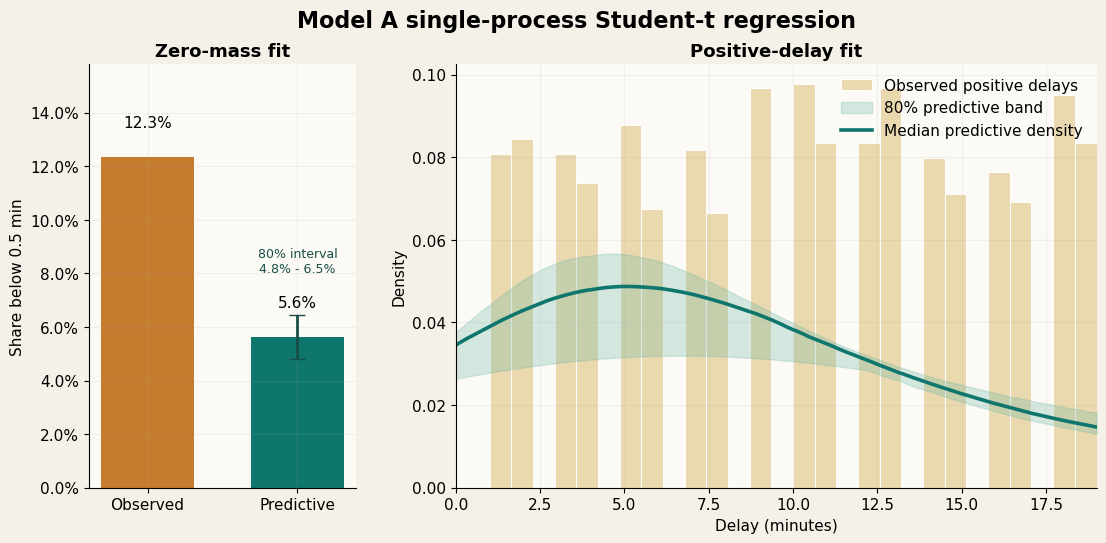

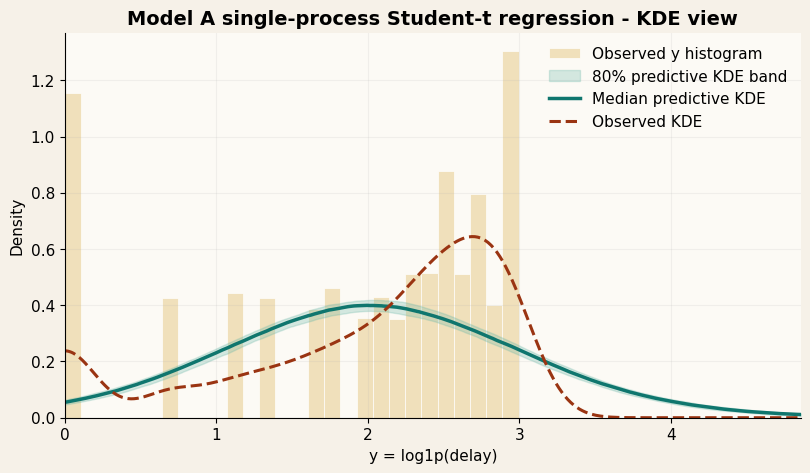

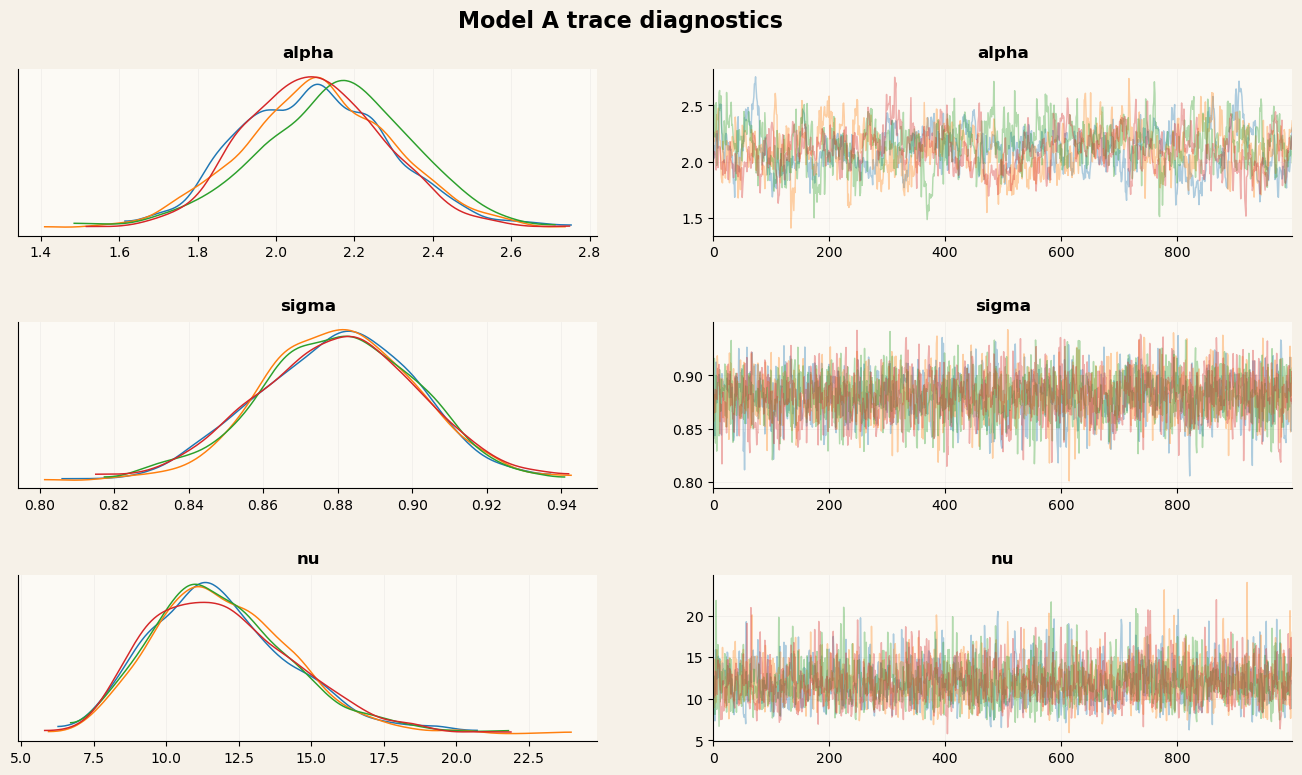

In [7]:
plot_delay_ppc(idata_a, "Model A single-process Student-t regression", zero_mode="approx")
plot_delay_ppc_kde(idata_a, "Model A single-process Student-t regression")

plot_trace_clean(
    idata_a,
    var_names=["alpha", "sigma", "nu"],
    title="Model A trace diagnostics",
    figsize=(14, 8),
)
plt.show()


## Step 6 Model B: two-regime robust mixture regression

The regime means share the same covariate effects and differ by a positive offset `delta`, which keeps the component ordering identifiable.


In [ ]:
model_b_code = """
data {
  int<lower=1> N;
  int<lower=1> K;
  matrix[N, K] X;
  vector[N] y;
  real y_bar;
}
parameters {
  real alpha1;
  vector[K] beta1;
  real<lower=0> delta;
  real<lower=0> sigma1;
  real<lower=0> sigma2;
  real<lower=0, upper=1> w;
  real<lower=0> nu1_minus2;
  real<lower=0> nu2_minus2;
}
transformed parameters {
  real<lower=2> nu1 = nu1_minus2 + 2;
  real<lower=2> nu2 = nu2_minus2 + 2;
  vector[N] mu1 = alpha1 + X * beta1;
  vector[N] mu2 = mu1 + delta;
}
model {
  alpha1 ~ normal(y_bar, 2);
  beta1 ~ normal(0, 1);
  delta ~ exponential(1);
  sigma1 ~ exponential(1);
  sigma2 ~ exponential(1);
  w ~ beta(2, 2);
  nu1_minus2 ~ exponential(1);
  nu2_minus2 ~ exponential(1);
  for (n in 1:N) {
    target += log_mix(
      w,
      student_t_lpdf(y[n] | nu1, mu1[n], sigma1),
      student_t_lpdf(y[n] | nu2, mu2[n], sigma2)
    );
  }
}
generated quantities {
  vector[N] log_lik;
  vector[N] y_rep;
  for (n in 1:N) {
    real lp1 = student_t_lpdf(y[n] | nu1, mu1[n], sigma1);
    real lp2 = student_t_lpdf(y[n] | nu2, mu2[n], sigma2);
    log_lik[n] = log_mix(w, lp1, lp2) - y[n];
    if (bernoulli_rng(w) == 1)
      y_rep[n] = student_t_rng(nu1, mu1[n], sigma1);
    else
      y_rep[n] = student_t_rng(nu2, mu2[n], sigma2);
  }
}
"""
model_b_path = write_stan_file("model_b_mixture_regression.stan", model_b_code)
model_b = load_cmdstan_model(model_b_path)
init_b = {
    "alpha1": y_bar,
    "beta1": np.zeros(K),
    "delta": 0.30,
    "sigma1": 0.40,
    "sigma2": 0.80,
    "w": 0.50,
    "nu1_minus2": 10.0,
    "nu2_minus2": 10.0,
}
fit_b = model_b.sample(
    data={"N": N, "K": K, "X": X, "y": y, "y_bar": y_bar},
    inits=init_b,
    **SAMPLE_ARGS,
)
idata_b = make_idata(fit_b, y, feature_vars=["beta1"])
summary_b = select_summary_columns(
    az.summary(idata_b, var_names=["alpha1", "delta", "sigma1", "sigma2", "w", "nu1", "nu2"])
)
display(summary_b)


14:32:22 - cmdstanpy - WARNING - CmdStanModel(compile=...) is deprecated and will be removed in the next major version. The constructor will always ensure a model has a compiled executable.
If you wish to force recompilation, use force_compile=True instead.


Using existing executable: model_b_mixture_regression.exe (set FORCE_RECOMPILE=True to rebuild)


14:32:22 - cmdstanpy - INFO - CmdStan start processing


chain 1:   0%|          | 0/2000 [00:00<?, ?it/s, (Warmup)]

chain 2:   0%|          | 0/2000 [00:00<?, ?it/s, (Warmup)]

chain 3:   0%|          | 0/2000 [00:00<?, ?it/s, (Warmup)]

chain 4:   0%|          | 0/2000 [00:00<?, ?it/s, (Warmup)]

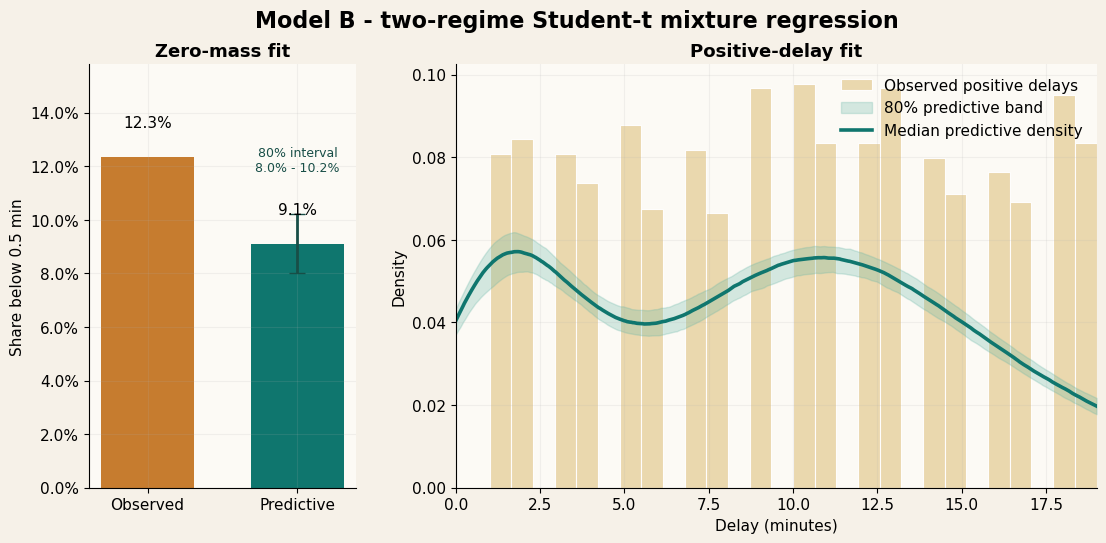

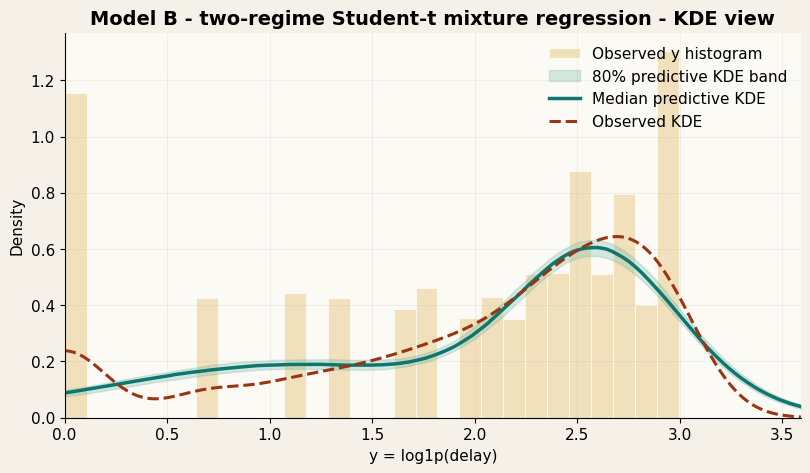

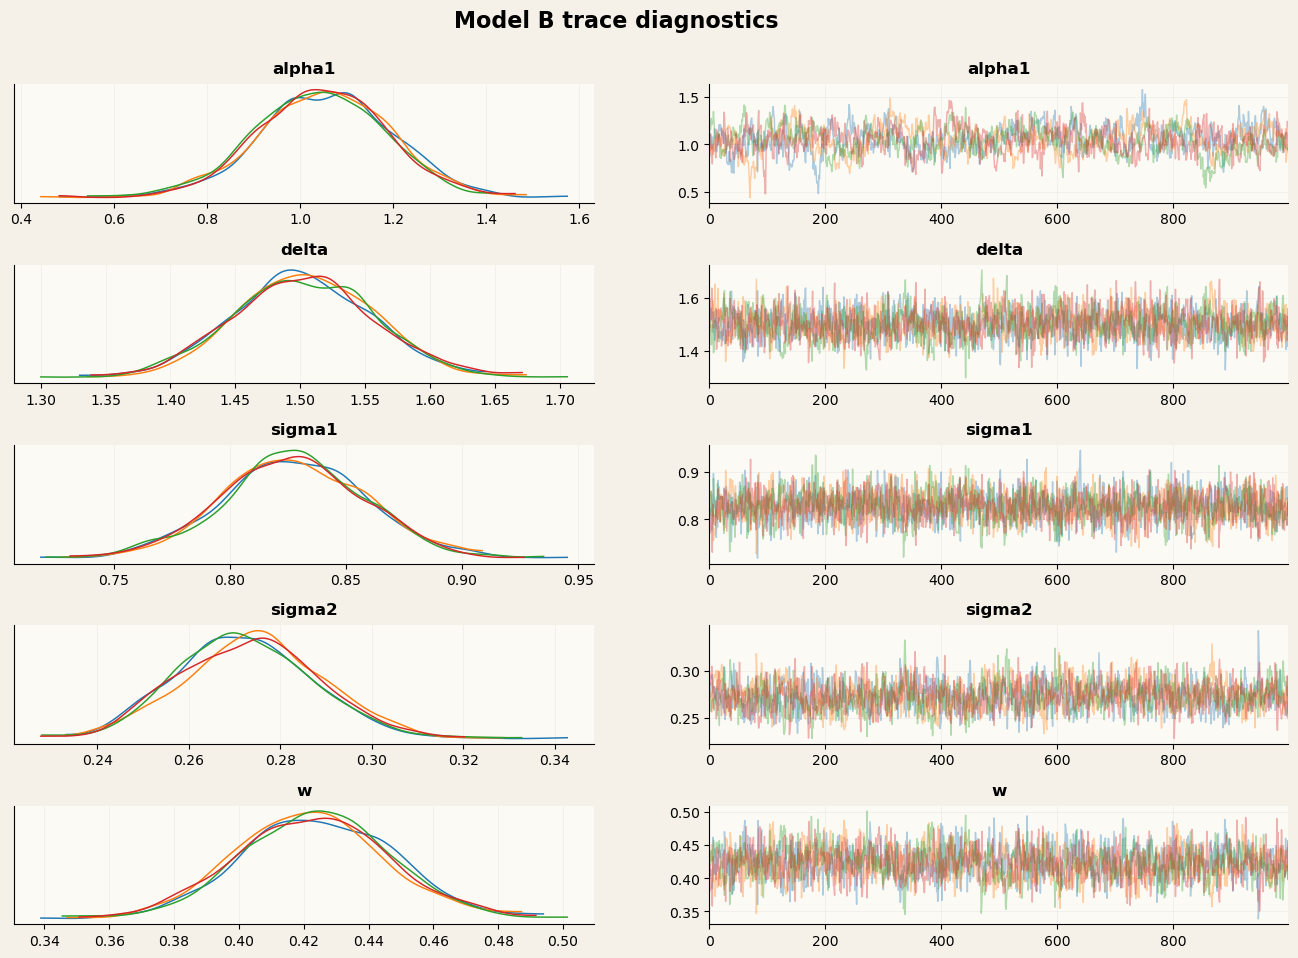

In [ ]:
plot_delay_ppc(idata_b, "Model B - two-regime Student-t mixture regression", zero_mode="approx")
plot_delay_ppc_kde(idata_b, "Model B - two-regime Student-t mixture regression")

plot_trace_clean(
    idata_b,
    var_names=["alpha1", "delta", "sigma1", "sigma2", "w"],
    title="Model B trace diagnostics",
    figsize=(14, 10),
)
plt.show()


## Step 7  Model C: hurdle lognormal regression

This uses a covariate-dependent Bernoulli gate for zero vs positive delay and a lognormal model on the original delay scale for the positive part.
That keeps the zero spike explicit and makes the full model practical to run locally.


In [ ]:
model_c_code = """
data {
  int<lower=1> N;
  int<lower=1> K;
  matrix[N, K] X;
  array[N] real<lower=0> delay;
  array[N] int<lower=0, upper=1> z;
  real log_delay_pos_mean;
  real logit_positive_rate;
}
parameters {
  real alpha_z;
  vector[K] beta_z;
  real alpha_d;
  vector[K] beta_d;
  real<lower=0> sigma_d;
}
transformed parameters {
  vector[N] eta = alpha_z + X * beta_z;
  vector[N] mu_d = alpha_d + X * beta_d;
}
model {
  alpha_z ~ normal(logit_positive_rate, 1.5);
  beta_z ~ normal(0, 1);
  alpha_d ~ normal(log_delay_pos_mean, 2);
  beta_d ~ normal(0, 1);
  sigma_d ~ exponential(1);
  for (n in 1:N) {
    target += bernoulli_logit_lpmf(z[n] | eta[n]);
    if (z[n] == 1) {
      target += lognormal_lpdf(delay[n] | mu_d[n], sigma_d);
    }
  }
}
generated quantities {
  vector[N] log_lik;
  vector[N] y_rep;
  for (n in 1:N) {
    if (z[n] == 1) {
      log_lik[n] = bernoulli_logit_lpmf(1 | eta[n]) + lognormal_lpdf(delay[n] | mu_d[n], sigma_d);
    } else {
      log_lik[n] = bernoulli_logit_lpmf(0 | eta[n]);
    }
    if (bernoulli_logit_rng(eta[n]) == 1) {
      real d_rep = lognormal_rng(mu_d[n], sigma_d);
      y_rep[n] = log1p(d_rep);
    } else {
      y_rep[n] = 0;
    }
  }
}
"""
model_c_path = write_stan_file("model_c_hurdle_lognormal.stan", model_c_code)
model_c = load_cmdstan_model(model_c_path)
init_c = {
    "alpha_z": logit_positive_rate,
    "beta_z": np.zeros(K),
    "alpha_d": log_delay_pos_mean,
    "beta_d": np.zeros(K),
    "sigma_d": 0.60,
}
fit_c = model_c.sample(
    data={
        "N": N,
        "K": K,
        "X": X,
        "delay": delay,
        "z": z.astype(int),
        "log_delay_pos_mean": log_delay_pos_mean,
        "logit_positive_rate": logit_positive_rate,
    },
    inits=init_c,
    **SAMPLE_ARGS,
)
idata_c = make_idata(fit_c, y, feature_vars=["beta_z", "beta_d"])
summary_c = select_summary_columns(
    az.summary(idata_c, var_names=["alpha_z", "alpha_d", "sigma_d"])
)
display(summary_c)


12:26:23 - cmdstanpy - INFO - compiling stan file D:\ABDA\stan_models\model_c_hurdle_lognormal.stan to exe file D:\ABDA\stan_models\model_c_hurdle_lognormal.exe
12:26:42 - cmdstanpy - INFO - compiled model executable: D:\ABDA\stan_models\model_c_hurdle_lognormal.exe
12:26:42 - cmdstanpy - INFO - CmdStan start processing


chain 1:   0%|          | 0/2000 [00:00<?, ?it/s, (Warmup)]

chain 2:   0%|          | 0/2000 [00:00<?, ?it/s, (Warmup)]

chain 3:   0%|          | 0/2000 [00:00<?, ?it/s, (Warmup)]

chain 4:   0%|          | 0/2000 [00:00<?, ?it/s, (Warmup)]

12:34:47 - cmdstanpy - INFO - CmdStan done processing.
12:34:47 - cmdstanpy - WARNING - Non-fatal error during sampling:
Exception: lognormal_lpdf: Scale parameter is inf, but must be positive finite! (in 'model_c_hurdle_lognormal.stan', line 31, column 6 to column 60)
Exception: lognormal_lpdf: Scale parameter is inf, but must be positive finite! (in 'model_c_hurdle_lognormal.stan', line 31, column 6 to column 60)
Exception: lognormal_lpdf: Scale parameter is inf, but must be positive finite! (in 'model_c_hurdle_lognormal.stan', line 31, column 6 to column 60)
Consider re-running with show_console=True if the above output is unclear!


,mean,sd,hdi_2.5%,hdi_97.5%,r_hat,ess_bulk
alpha_z,2.493,0.405,1.695,3.265,1.00,1788.0
alpha_d,2.045,0.190,1.674,2.405,1.01,419.0
sigma_d,0.787,0.014,0.760,0.814,1.00,5929.0


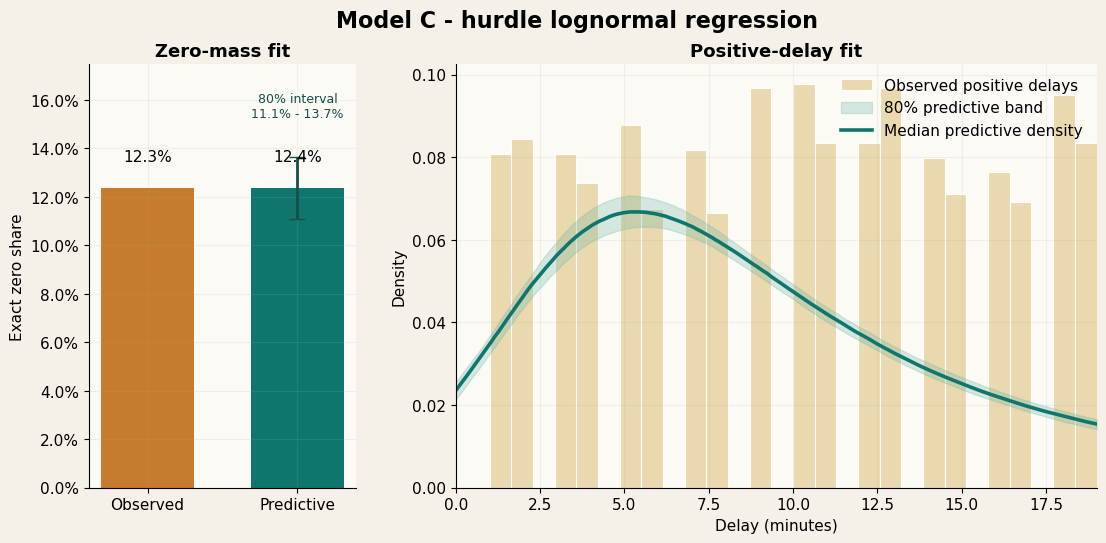

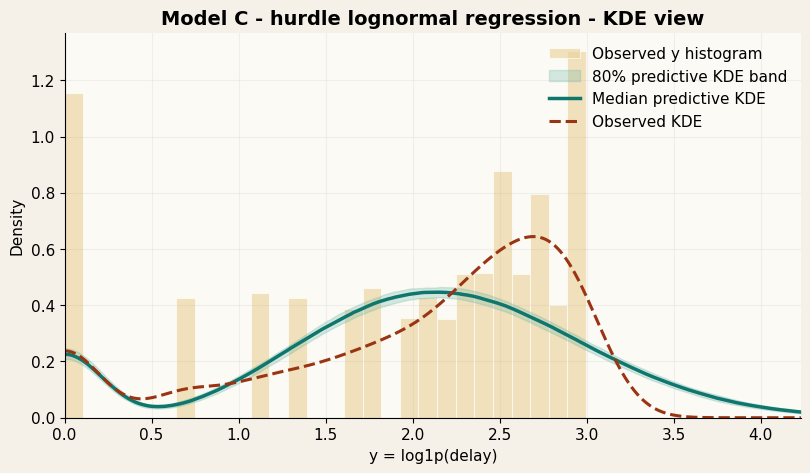

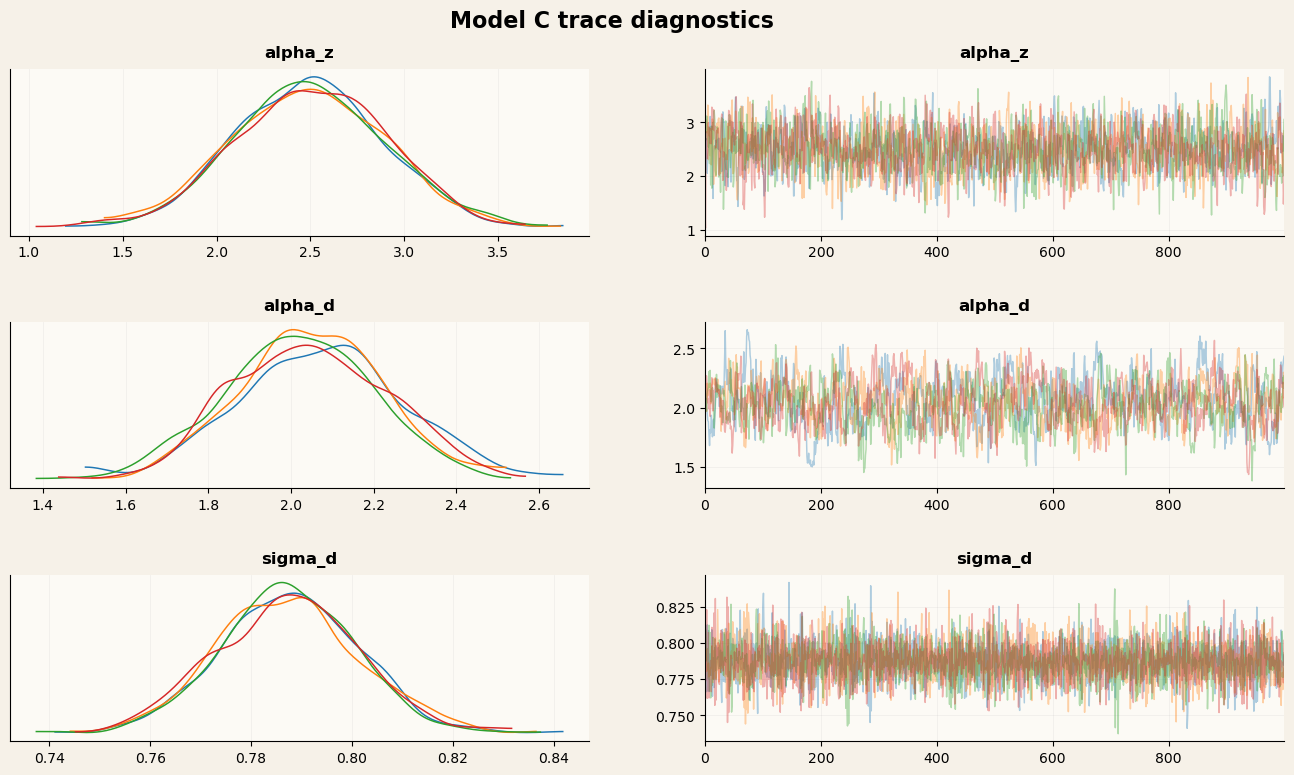

In [ ]:
plot_delay_ppc(idata_c, "Model C - hurdle lognormal regression", zero_mode="exact")
plot_delay_ppc_kde(idata_c, "Model C - hurdle lognormal regression")

plot_trace_clean(
    idata_c,
    var_names=["alpha_z", "alpha_d", "sigma_d"],
    title="Model C trace diagnostics",
    figsize=(14, 8),
)
plt.show()


Issue?? the whole positive part is modeled by one single lognormal family, just with predictor-dependent mean.

## Step 8 - Model D: hierarchical Student-t regression with route-level partial pooling

Partial pooling gives each route its own intercept while shrinking route effects back toward zero unless the data strongly support a route-specific deviation.
This is useful for prediction because sparse routes borrow strength from the full dataset instead of getting unstable route-specific estimates.


In [ ]:
model_d_code = """
data {
  int<lower=1> N;
  int<lower=1> K;
  int<lower=1> J_route;
  matrix[N, K] X;
  array[N] int<lower=1, upper=J_route> route_id;
  vector[N] y;
}
parameters {
  real alpha;
  vector[K] beta;
  real<lower=0> sigma;
  real<lower=0> nu_minus2;
  real<lower=0> tau_route;
  vector[J_route] z_route;
}
transformed parameters {
  real<lower=2> nu = nu_minus2 + 2;
  vector[J_route] a_route = tau_route * z_route;
  vector[N] mu = alpha + X * beta;
  for (n in 1:N) {
    mu[n] += a_route[route_id[n]];
  }
}
model {
  alpha ~ normal(0, 2);
  beta ~ normal(0, 1);
  sigma ~ exponential(1);
  nu_minus2 ~ exponential(1);
  tau_route ~ exponential(1);
  z_route ~ normal(0, 1);

  y ~ student_t(nu, mu, sigma);
}
generated quantities {
  vector[N] log_lik;
  vector[N] y_rep;
  for (n in 1:N) {
    log_lik[n] = student_t_lpdf(y[n] | nu, mu[n], sigma);
    y_rep[n] = student_t_rng(nu, mu[n], sigma);
  }
}
"""

model_d_path = write_stan_file("model_d_hierarchical_route.stan", model_d_code)
model_d = load_cmdstan_model(model_d_path)
init_d = {
    "alpha": y_bar,
    "beta": np.zeros(K_hier),
    "sigma": 0.50,
    "nu_minus2": 10.0,
    "tau_route": 0.30,
    "z_route": np.zeros(J_route),
}
sample_args_d = SAMPLE_ARGS.copy()
fit_d = model_d.sample(
    data={"N": N, "K": K_hier, "J_route": J_route, "X": X_hier, "route_id": route_idx, "y": y},
    inits=init_d,
    **sample_args_d,
)
n_div_d = divergence_count(fit_d)
if n_div_d > 0:
    print(f"Refitting Model D after {n_div_d} divergent transitions with stricter NUTS controls.")
    sample_args_d.update({"adapt_delta": 0.995, "max_treedepth": 16})
    fit_d = model_d.sample(
        data={"N": N, "K": K_hier, "J_route": J_route, "X": X_hier, "route_id": route_idx, "y": y},
        inits=init_d,
        **sample_args_d,
    )

idata_d = make_idata(
    fit_d,
    y,
    feature_vars=["beta"],
    feature_names_override=feature_names_hier,
    extra_coords={"route": route_levels},
    extra_dims={"z_route": ["route"], "a_route": ["route"]},
)
idata_d = adjust_loglik_to_delay_scale(idata_d, y)

summary_d = select_summary_columns(az.summary(idata_d, var_names=["tau_route", "sigma", "nu"]))
route_effects_d = varying_effect_summary(fit_d, "a_route", route_levels, top_n=8)
display(summary_d)
display(route_effects_d)


12:35:02 - cmdstanpy - WARNING - CmdStanModel(compile=...) is deprecated and will be removed in the next major version. The constructor will always ensure a model has a compiled executable.
If you wish to force recompilation, use force_compile=True instead.


Using existing executable: model_d_hierarchical_route.exe (set FORCE_RECOMPILE=True to rebuild)


12:35:03 - cmdstanpy - INFO - CmdStan start processing


chain 1:   0%|          | 0/2000 [00:00<?, ?it/s, (Warmup)]

chain 2:   0%|          | 0/2000 [00:00<?, ?it/s, (Warmup)]

chain 3:   0%|          | 0/2000 [00:00<?, ?it/s, (Warmup)]

chain 4:   0%|          | 0/2000 [00:00<?, ?it/s, (Warmup)]

12:36:58 - cmdstanpy - INFO - CmdStan done processing.
12:36:58 - cmdstanpy - WARNING - Non-fatal error during sampling:
Exception: student_t_lpdf: Scale parameter is inf, but must be positive finite! (in 'model_d_hierarchical_route.stan', line 34, column 2 to column 31)
	Exception: student_t_lpdf: Scale parameter is inf, but must be positive finite! (in 'model_d_hierarchical_route.stan', line 34, column 2 to column 31)
	Exception: student_t_lpdf: Scale parameter is inf, but must be positive finite! (in 'model_d_hierarchical_route.stan', line 34, column 2 to column 31)
Exception: student_t_lpdf: Scale parameter is inf, but must be positive finite! (in 'model_d_hierarchical_route.stan', line 34, column 2 to column 31)
	Exception: student_t_lpdf: Scale parameter is inf, but must be positive finite! (in 'model_d_hierarchical_route.stan', line 34, column 2 to column 31)
	Exception: student_t_lpdf: Scale parameter is inf, but must be positive finite! (in 'model_d_hierarchical_route.stan', l

,mean,sd,hdi_2.5%,hdi_97.5%,r_hat,ess_bulk
tau_route,0.029,0.022,0.000,0.071,1.0,2160.0
sigma,0.877,0.021,0.835,0.919,1.0,4895.0
nu,11.682,2.396,7.560,16.770,1.0,5178.0


,group,mean,median,q05,q95
0,Route_2,0.019028,0.007647,-0.023610,0.096563
1,Route_19,-0.013826,-0.005291,-0.079420,0.026940
2,Route_14,0.011894,0.003672,-0.031946,0.080904
3,Route_18,-0.010603,-0.003299,-0.074813,0.033533
4,Route_13,0.010167,0.003363,-0.033648,0.073368
5,Route_12,-0.008378,-0.002148,-0.075248,0.039362
6,Route_11,0.007610,0.002179,-0.040808,0.068134
7,Route_15,0.007279,0.002205,-0.040169,0.064782


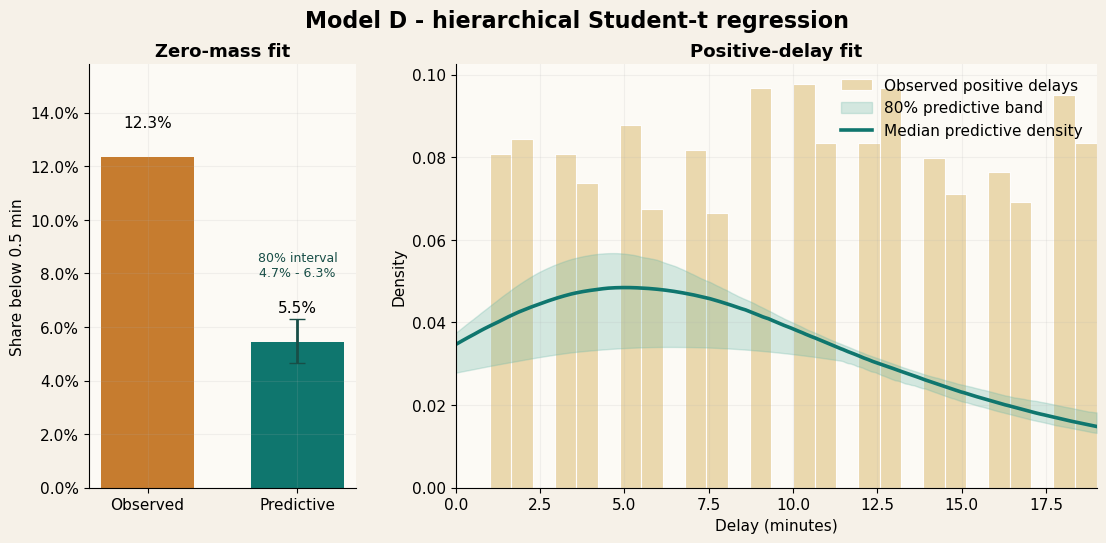

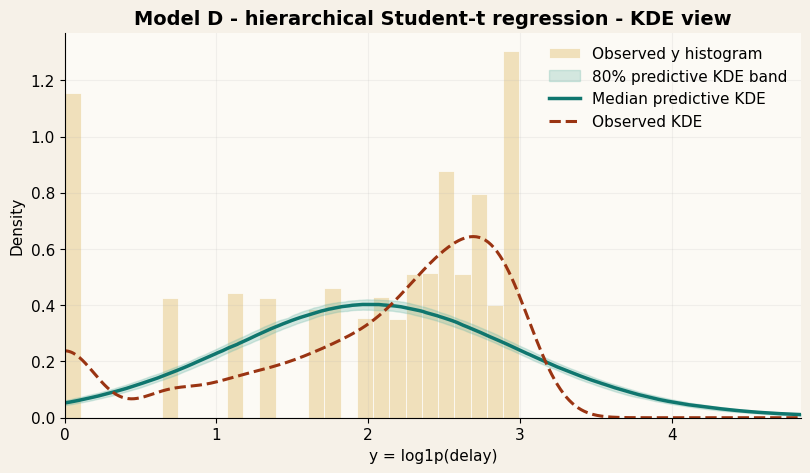

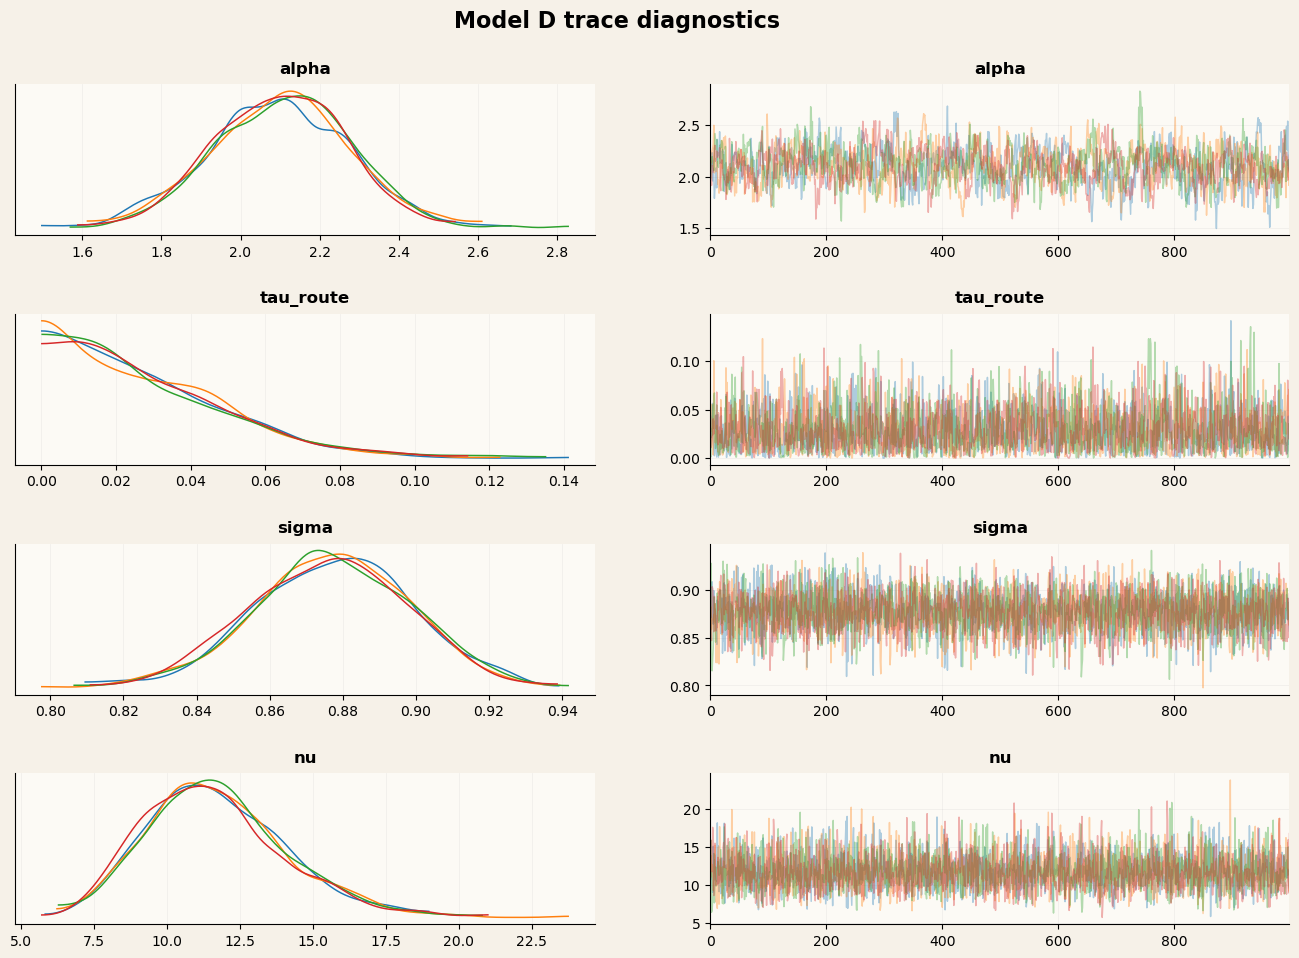

In [ ]:
plot_delay_ppc(idata_d, "Model D - hierarchical Student-t regression", zero_mode="approx")
plot_delay_ppc_kde(idata_d, "Model D - hierarchical Student-t regression")

plot_trace_clean(
    idata_d,
    var_names=["alpha", "tau_route", "sigma", "nu"],
    title="Model D trace diagnostics",
    figsize=(14, 10),
)
plt.show()


## Step 9 - LOO comparison and posterior predictive summaries

`log_lik` for Models A, B, and D is adjusted to the original delay-minute scale using the Jacobian term `-y`.
Model C is already defined on the original delay scale.


,rank,elpd_loo,p_loo,elpd_diff,weight,se,dse,warning,scale
Model B,0,-6256.338809,163.569743,0.000000,8.934012e-01,23.663504,0.000000,False,log
Model C,1,-6601.758940,271.451792,345.420131,1.065988e-01,32.840825,30.459563,False,log
Model D,2,-6728.447186,127.952591,472.108377,1.302234e-10,29.281838,26.848774,False,log
Model A,3,-6742.131337,145.646573,485.792527,1.569125e-10,29.644172,26.989132,False,log


,max_k,share_k_gt_0.7
Model A,0.358934,0.0
Model B,0.416542,0.0
Model C,0.553970,0.0
Model D,0.376151,0.0


,mean,q025,q975,observed_zero_share
model,,,,
Model A (<0.5 min),0.056247,0.0445,0.0695,0.1235
Model B (<0.5 min),0.090885,0.0750,0.1080,0.1235
Model C (=0),0.123655,0.1045,0.1440,0.1235
Model D (<0.5 min),0.054549,0.0425,0.0675,0.1235


,pred_q90_mean,pred_q90_obs,pred_q99_mean,pred_q99_obs
model,,,,
Model A,26.172992,18.0,90.370088,19.0
Model B,18.140854,18.0,30.122076,19.0
Model C,22.117410,18.0,54.261153,19.0
Model D,25.928318,18.0,89.415520,19.0


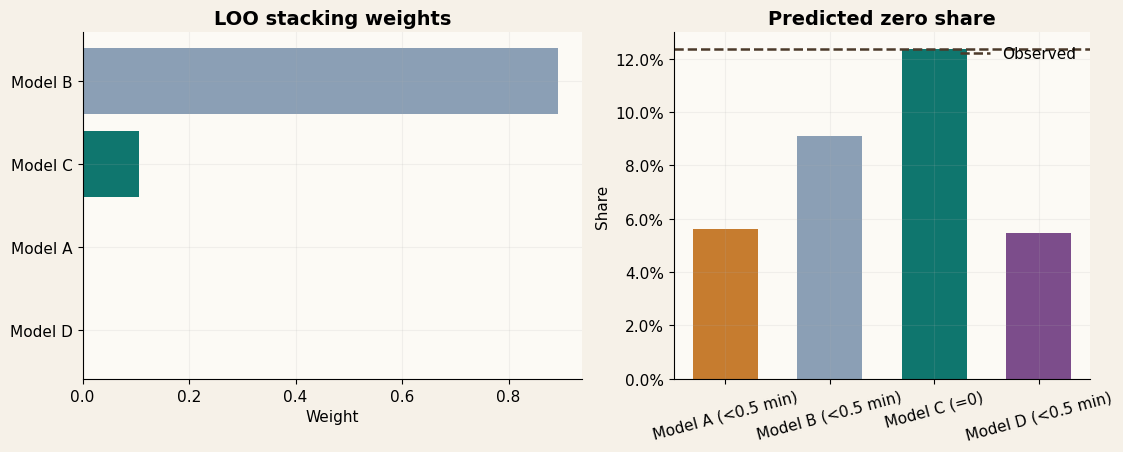

In [ ]:
loo_a = az.loo(idata_a, pointwise=True)
loo_b = az.loo(idata_b, pointwise=True)
loo_c = az.loo(idata_c, pointwise=True)
loo_d = az.loo(idata_d, pointwise=True)

cmp_all = az.compare(
    {
        "Model A": idata_a,
        "Model B": idata_b,
        "Model C": idata_c,
        "Model D": idata_d,
    },
    ic="loo",
)
display(cmp_all)

pareto_summary = pd.DataFrame(
    {
        "max_k": [
            float(np.max(loo_a.pareto_k.values)),
            float(np.max(loo_b.pareto_k.values)),
            float(np.max(loo_c.pareto_k.values)),
            float(np.max(loo_d.pareto_k.values)),
        ],
        "share_k_gt_0.7": [
            float(np.mean(loo_a.pareto_k.values > 0.7)),
            float(np.mean(loo_b.pareto_k.values > 0.7)),
            float(np.mean(loo_c.pareto_k.values > 0.7)),
            float(np.mean(loo_d.pareto_k.values > 0.7)),
        ],
    },
    index=["Model A", "Model B", "Model C", "Model D"],
)

zero_summary = pd.DataFrame(
    [
        zero_share_summary(idata_a, "Model A (<0.5 min)", exact=False),
        zero_share_summary(idata_b, "Model B (<0.5 min)", exact=False),
        zero_share_summary(idata_c, "Model C (=0)", exact=True),
        zero_share_summary(idata_d, "Model D (<0.5 min)", exact=False),
    ]
).set_index("model")

tail_summary = pd.DataFrame(
    [
        tail_quantile_summary(idata_a, "Model A"),
        tail_quantile_summary(idata_b, "Model B"),
        tail_quantile_summary(idata_c, "Model C"),
        tail_quantile_summary(idata_d, "Model D"),
    ]
).set_index("model")

display(pareto_summary)
display(zero_summary)
display(tail_summary)

model_colors = {
    "Model A": "#c67c2f",
    "Model B": "#8b9fb5",
    "Model C": "#0f766e",
    "Model D": "#7c4d8b",
}

fig, axes = plt.subplots(1, 2, figsize=(13, 4.5), gridspec_kw={"width_ratios": [1.2, 1.0]})

weights = cmp_all["weight"].sort_values(ascending=True)
axes[0].barh(weights.index, weights.values, color=[model_colors[name] for name in weights.index])
axes[0].set_title("LOO stacking weights")
axes[0].set_xlabel("Weight")

zero_means = zero_summary["mean"].to_numpy()
zero_labels = zero_summary.index.tolist()
axes[1].bar(zero_labels, zero_means, color=["#c67c2f", "#8b9fb5", "#0f766e", "#7c4d8b"], width=0.62)
axes[1].axhline(np.mean(delay == 0), color="#4b3a2a", linestyle="--", linewidth=1.8, label="Observed")
axes[1].yaxis.set_major_formatter(PercentFormatter(1.0))
axes[1].set_title("Predicted zero share")
axes[1].set_ylabel("Share")
axes[1].tick_params(axis="x", rotation=15)
axes[1].legend(loc="upper right")

plt.show()


## Step 10 - Covariate and route effects worth inspecting


In [ ]:
coef_a = posterior_coef_summary(fit_a, "beta", feature_names, top_n=12)
coef_b = posterior_coef_summary(fit_b, "beta1", feature_names, top_n=12)
coef_c_gate = posterior_coef_summary(fit_c, "beta_z", feature_names, top_n=12)
coef_c_pos = posterior_coef_summary(fit_c, "beta_d", feature_names, top_n=12)
coef_d = posterior_coef_summary(fit_d, "beta", feature_names_hier, top_n=12)
route_effects_d = varying_effect_summary(fit_d, "a_route", route_levels, top_n=8)

print("Top effects for Model A")
display(coef_a)
print("Top shared effects for Model B")
display(coef_b)
print("Top effects for Model C gate: positive vs zero")
display(coef_c_gate)
print("Top effects for Model C positive-delay size")
display(coef_c_pos)
print("Top fixed effects for Model D")
display(coef_d)
print("Largest route-level intercept adjustments in Model D")
display(route_effects_d)


Top effects for Model A


,feature,mean,median,q05,q95
0,destination_station_Station_5,-0.372442,-0.372863,-0.723877,-0.031960
1,destination_station_Station_37,0.367650,0.370728,0.063343,0.671480
2,destination_station_Station_39,-0.352047,-0.351292,-0.680899,-0.023501
3,origin_station_Station_38,0.336321,0.335012,0.058154,0.623806
4,origin_station_Station_9,-0.323278,-0.325480,-0.650494,0.001334
5,destination_station_Station_27,0.299116,0.297695,-0.007250,0.603990
6,destination_station_Station_10,-0.298389,-0.296638,-0.609922,0.005664
7,destination_station_Station_17,0.283377,0.284088,-0.013002,0.563855
8,destination_station_Station_15,0.266913,0.267567,-0.033485,0.575341
9,origin_station_Station_40,0.265629,0.265289,-0.008190,0.544147


Top shared effects for Model B


,feature,mean,median,q05,q95
0,destination_station_Station_2,-0.340830,-0.343784,-0.519439,-0.163900
1,origin_station_Station_23,0.304616,0.304475,0.134212,0.481255
2,origin_station_Station_34,0.302908,0.301329,0.121756,0.487061
3,origin_station_Station_33,0.301379,0.303110,0.124754,0.475202
4,origin_station_Station_44,0.299761,0.299085,0.140280,0.466994
5,origin_station_Station_12,0.295670,0.296652,0.126802,0.460505
6,origin_station_Station_17,0.283681,0.284206,0.125046,0.439417
7,origin_station_Station_38,0.280491,0.279774,0.117706,0.441540
8,origin_station_Station_20,0.271853,0.272994,0.106143,0.435100
9,origin_station_Station_37,0.266711,0.267878,0.096504,0.436098


Top effects for Model C gate: positive vs zero


...

,feature,mean,median,q05,q95
0,destination_station_Station_37,0.399918,0.402421,0.127164,0.674871
1,destination_station_Station_17,0.322951,0.323332,0.055283,0.593710
2,destination_station_Station_19,0.303345,0.302892,0.015438,0.578808
3,destination_station_Station_15,0.300260,0.299677,0.017667,0.583658
4,destination_station_Station_28,0.286455,0.288018,-0.009294,0.563648
5,destination_station_Station_33,0.279707,0.277532,-0.007630,0.570939
6,destination_station_Station_29,0.269016,0.268809,-0.012577,0.548486
7,destination_station_Station_8,0.264024,0.264431,-0.051451,0.581438
8,destination_station_Station_38,0.259603,0.262157,-0.053574,0.567942
9,destination_station_Station_34,0.249818,0.249597,-0.033638,0.532125


Top fixed effects for Model D


,feature,mean,median,q05,q95
0,destination_station_Station_5,-0.381679,-0.382094,-0.733966,-0.034210
1,origin_station_Station_38,0.356722,0.356170,0.066495,0.639948
2,destination_station_Station_37,0.352445,0.353063,0.052147,0.655890
3,destination_station_Station_39,-0.338991,-0.337367,-0.668666,-0.005352
4,origin_station_Station_9,-0.294619,-0.287477,-0.619991,0.017909
5,destination_station_Station_27,0.292217,0.293718,-0.026888,0.607218
6,destination_station_Station_17,0.287480,0.287277,-0.001407,0.575186
7,origin_station_Station_40,0.279151,0.281371,0.009763,0.550631
8,destination_station_Station_10,-0.274098,-0.274102,-0.593114,0.053779
9,destination_station_Station_46,-0.263314,-0.261453,-0.588809,0.058029


Largest route-level intercept adjustments in Model D


,group,mean,median,q05,q95
0,Route_2,0.019028,0.007647,-0.023610,0.096563
1,Route_19,-0.013826,-0.005291,-0.079420,0.026940
2,Route_14,0.011894,0.003672,-0.031946,0.080904
3,Route_18,-0.010603,-0.003299,-0.074813,0.033533
4,Route_13,0.010167,0.003363,-0.033648,0.073368
5,Route_12,-0.008378,-0.002148,-0.075248,0.039362
6,Route_11,0.007610,0.002179,-0.040808,0.068134
7,Route_15,0.007279,0.002205,-0.040169,0.064782


## Step 11 - Energy diagnostics


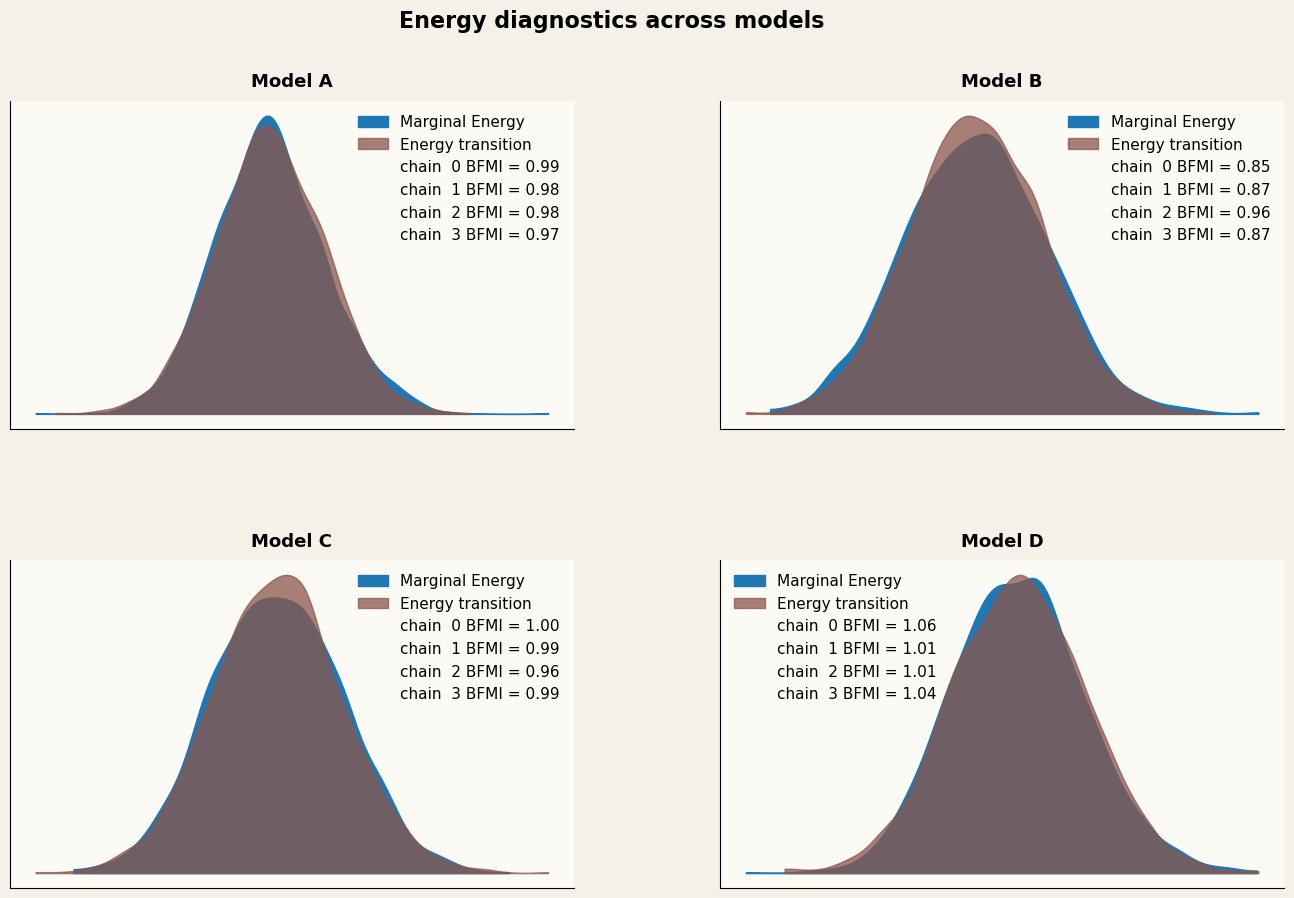

In [ ]:
plot_energy_grid(
    [
        ("Model A", idata_a),
        ("Model B", idata_b),
        ("Model C", idata_c),
        ("Model D", idata_d),
    ],
    title="Energy diagnostics across models",
)
plt.show()


## Step 12 - Tail PPC limitation for the mixture model

This tail-focused PPC is useful, but it has an important limitation:

- Model B is continuous on `y = log1p(delay)`, so it cannot place exact probability mass at `y = 0`.
- When the y-axis is on a log scale, even small mismatches near zero look much larger than they do on the natural scale.
- The curve shape also depends on kernel / smoothing choices inside the PPC display.

So this plot should be read as a tail-emphasis diagnostic, not as the only model-comparison figure. The main comparison should still rely on the full PPC set plus PSIS-LOO.


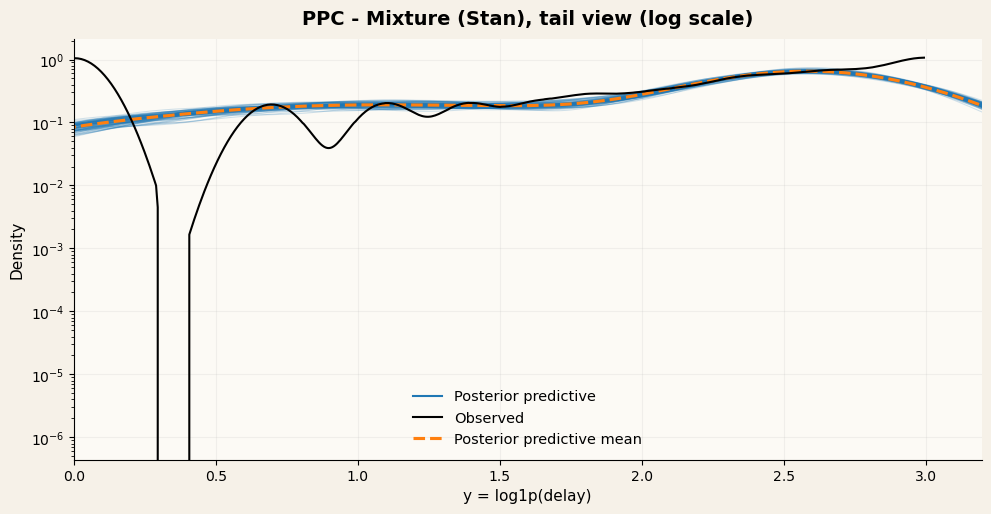

In [ ]:
plot_tail_ppc(
    idata_b,
    y_obs=y,
    title="PPC - Mixture (Stan), tail view (log scale)",
    num_pp_samples=100,
)
plt.show()


## Step 13 - Final predictive evaluation outputs
- Clean PSIS-LOO table, Pareto-k summary, and KDE-based PPC panels using existing fitted models




,Model,elpd_loo,SE(elpd_loo),LOOIC,SE(LOOIC),?LOOIC
0,Model B,-6256.339,23.664,12512.678,47.327,0.000
1,Model C,-6601.759,32.841,13203.518,65.682,690.840
2,Model D,-6728.447,29.282,13456.894,58.564,944.217
3,Model A,-6742.131,29.644,13484.263,59.288,971.585


,Model,n_obs,k > 0.5 (n),k > 0.5 (%),k > 0.7 (n),k > 0.7 (%),k > 1.0 (n),k > 1.0 (%)
0,Model B,2000,0,0.0,0,0.0,0,0.0
1,Model C,2000,2,0.1,0,0.0,0,0.0
2,Model D,2000,0,0.0,0,0.0,0,0.0
3,Model A,2000,0,0.0,0,0.0,0,0.0


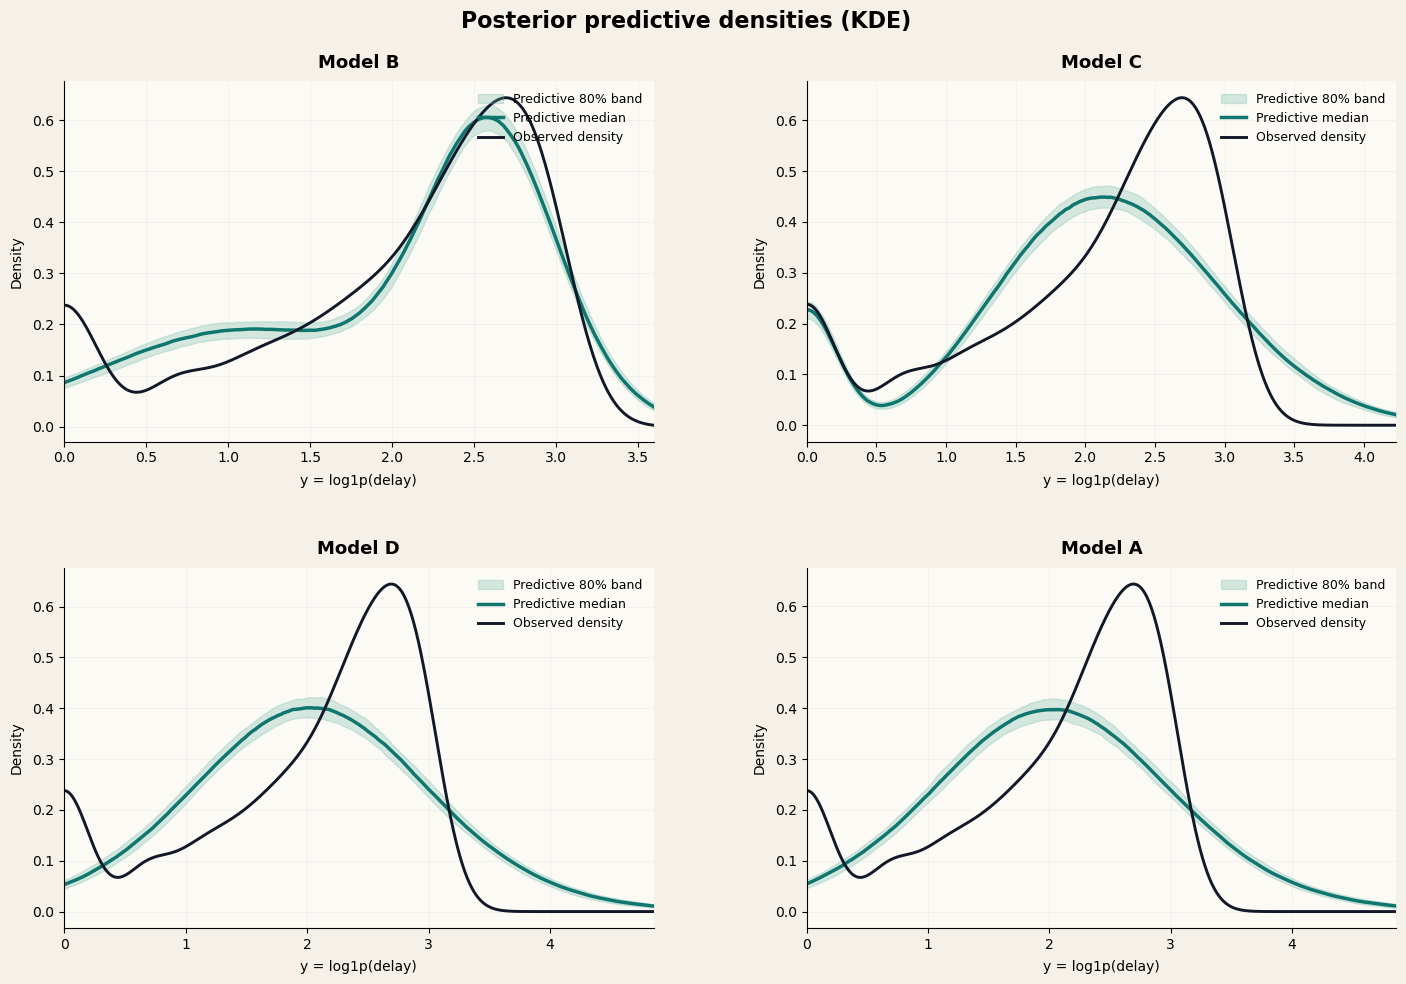

In [ ]:
candidate_order = [
    ("Model A", "idata_a"),
    ("Model B", "idata_b"),
    ("Model C", "idata_c"),
    ("Model D", "idata_d"),
    ("Single", "idata_single"),
    ("Mixture", "idata_mixture"),
    ("Zero-inflated", "idata_zi"),
]

model_map = {}
for label, var_name in candidate_order:
    obj = globals().get(var_name)
    if obj is not None and label not in model_map:
        model_map[label] = obj

if not model_map:
    raise RuntimeError("No idata_* objects found in the current session.")

# 1) Clean model comparison table (PSIS-LOO based)
loo_results = {name: az.loo(idata, pointwise=True) for name, idata in model_map.items()}

loo_rows = []
for name, loo_obj in loo_results.items():
    elpd = float(loo_obj.elpd_loo)
    se = float(loo_obj.se)
    loo_rows.append(
        {
            "Model": name,
            "elpd_loo": elpd,
            "SE(elpd_loo)": se,
            "LOOIC": -2.0 * elpd,
            "SE(LOOIC)": 2.0 * se,
        }
    )

loo_table = pd.DataFrame(loo_rows).sort_values("LOOIC", ascending=True).reset_index(drop=True)
loo_table["?LOOIC"] = loo_table["LOOIC"] - loo_table.loc[0, "LOOIC"]
loo_table = loo_table[["Model", "elpd_loo", "SE(elpd_loo)", "LOOIC", "SE(LOOIC)", "?LOOIC"]]
loo_table = loo_table.round(3)

# 2) Pareto-k diagnostic summary
pareto_rows = []
for name in loo_table["Model"]:
    loo_obj = loo_results[name]
    k_vals = np.asarray(loo_obj.pareto_k).ravel()
    n = len(k_vals)

    n_05 = int(np.sum(k_vals > 0.5))
    n_07 = int(np.sum(k_vals > 0.7))
    n_10 = int(np.sum(k_vals > 1.0))

    pareto_rows.append(
        {
            "Model": name,
            "n_obs": n,
            "k > 0.5 (n)": n_05,
            "k > 0.5 (%)": 100.0 * n_05 / n,
            "k > 0.7 (n)": n_07,
            "k > 0.7 (%)": 100.0 * n_07 / n,
            "k > 1.0 (n)": n_10,
            "k > 1.0 (%)": 100.0 * n_10 / n,
        }
    )

pareto_table = pd.DataFrame(pareto_rows).round({"k > 0.5 (%)": 2, "k > 0.7 (%)": 2, "k > 1.0 (%)": 2})

display(loo_table)
display(pareto_table)

# 3) Combined KDE-based PPC figure (one panel per model)
def get_y_obs_and_rep(idata):
    if "y" in idata.observed_data:
        y_obs = np.asarray(idata.observed_data["y"]).ravel()
    elif "delay" in idata.observed_data:
        y_obs = np.log1p(np.asarray(idata.observed_data["delay"]).ravel())
    else:
        obs_key = list(idata.observed_data.data_vars)[0]
        y_obs = np.asarray(idata.observed_data[obs_key]).ravel()

    pp_key = "y_rep" if "y_rep" in idata.posterior_predictive.data_vars else list(idata.posterior_predictive.data_vars)[0]
    y_rep = np.asarray(idata.posterior_predictive[pp_key])
    y_rep = y_rep.reshape(-1, y_rep.shape[-1])
    return y_obs, y_rep


def safe_kde(values, x_grid):
    vals = np.asarray(values, dtype=float)
    vals = vals[np.isfinite(vals)]
    if vals.size < 2:
        return np.full_like(x_grid, np.nan, dtype=float)
    if np.std(vals) < 1e-10:
        width = 0.02
        return np.exp(-0.5 * ((x_grid - vals.mean()) / width) ** 2) / (width * np.sqrt(2 * np.pi))
    return gaussian_kde(vals)(x_grid)


model_names = loo_table["Model"].tolist()
n_models = len(model_names)
n_cols = 2 if n_models > 1 else 1
n_rows = math.ceil(n_models / n_cols)

fig, axes = plt.subplots(n_rows, n_cols, figsize=(7.4 * n_cols, 5.1 * n_rows), squeeze=False)
rng_local = np.random.default_rng(42)

for panel_idx, model_name in enumerate(model_names):
    ax = axes[panel_idx // n_cols][panel_idx % n_cols]
    idata = model_map[model_name]
    y_obs, y_rep = get_y_obs_and_rep(idata)

    merged = np.concatenate([y_obs, y_rep.reshape(-1)])
    merged = merged[np.isfinite(merged)]
    x_max = float(np.quantile(merged, 0.995))
    x = np.linspace(0.0, max(0.25, x_max), 500)

    obs_kde = safe_kde(y_obs, x)

    draw_idx = rng_local.choice(y_rep.shape[0], size=min(250, y_rep.shape[0]), replace=False)
    dens = []
    for d in draw_idx:
        kde_line = safe_kde(y_rep[d], x)
        if np.all(np.isfinite(kde_line)):
            dens.append(kde_line)
    if not dens:
        dens = [safe_kde(y_rep.reshape(-1), x)]

    dens = np.vstack(dens)
    d_med = np.median(dens, axis=0)
    d_lo = np.quantile(dens, 0.10, axis=0)
    d_hi = np.quantile(dens, 0.90, axis=0)

    ax.fill_between(x, d_lo, d_hi, color="#6bb8a9", alpha=0.28, label="Predictive 80% band")
    ax.plot(x, d_med, color="#0f766e", linewidth=2.5, label="Predictive median")
    ax.plot(x, obs_kde, color="#111827", linewidth=2.1, label="Observed density")

    ax.set_xlim(0, max(0.25, x_max))
    ax.set_xlabel("y = log1p(delay)", fontsize=10, labelpad=6)
    ax.set_ylabel("Density", fontsize=10, labelpad=6)
    ax.set_title(model_name, fontsize=13, fontweight="bold", pad=10)
    ax.tick_params(axis="both", labelsize=10)
    ax.legend(loc="upper right", fontsize=9)
    ax.set_facecolor("#fcfaf5")
    ax.grid(alpha=0.15, linewidth=0.6)

for empty_idx in range(n_models, n_rows * n_cols):
    axes[empty_idx // n_cols][empty_idx % n_cols].axis("off")

fig.suptitle("Posterior predictive densities (KDE)", fontsize=16, fontweight="bold", y=0.99)
fig.subplots_adjust(top=0.92, bottom=0.09, left=0.08, right=0.98, hspace=0.35, wspace=0.26)
plt.show()


## Step 14: Legacy parity extras (tail + diagnostics)
Includes additional diagnostics from the older notebook, adapted to the current A/B/C/D model setup.

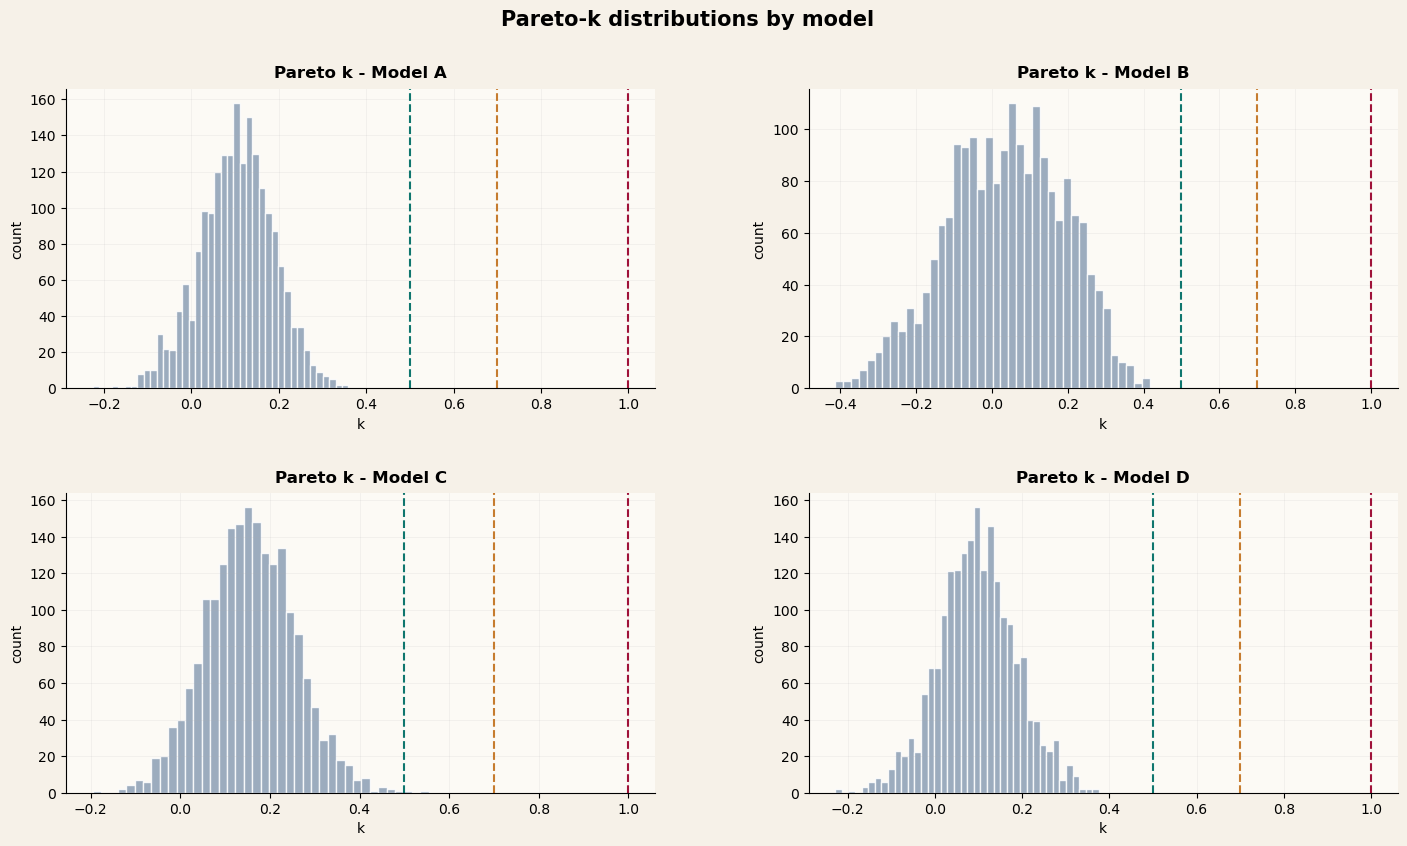

,max_k,share_k_gt_0.7
Model,,
Model A,0.3589,0.0
Model B,0.4165,0.0
Model C,0.5540,0.0
Model D,0.3762,0.0


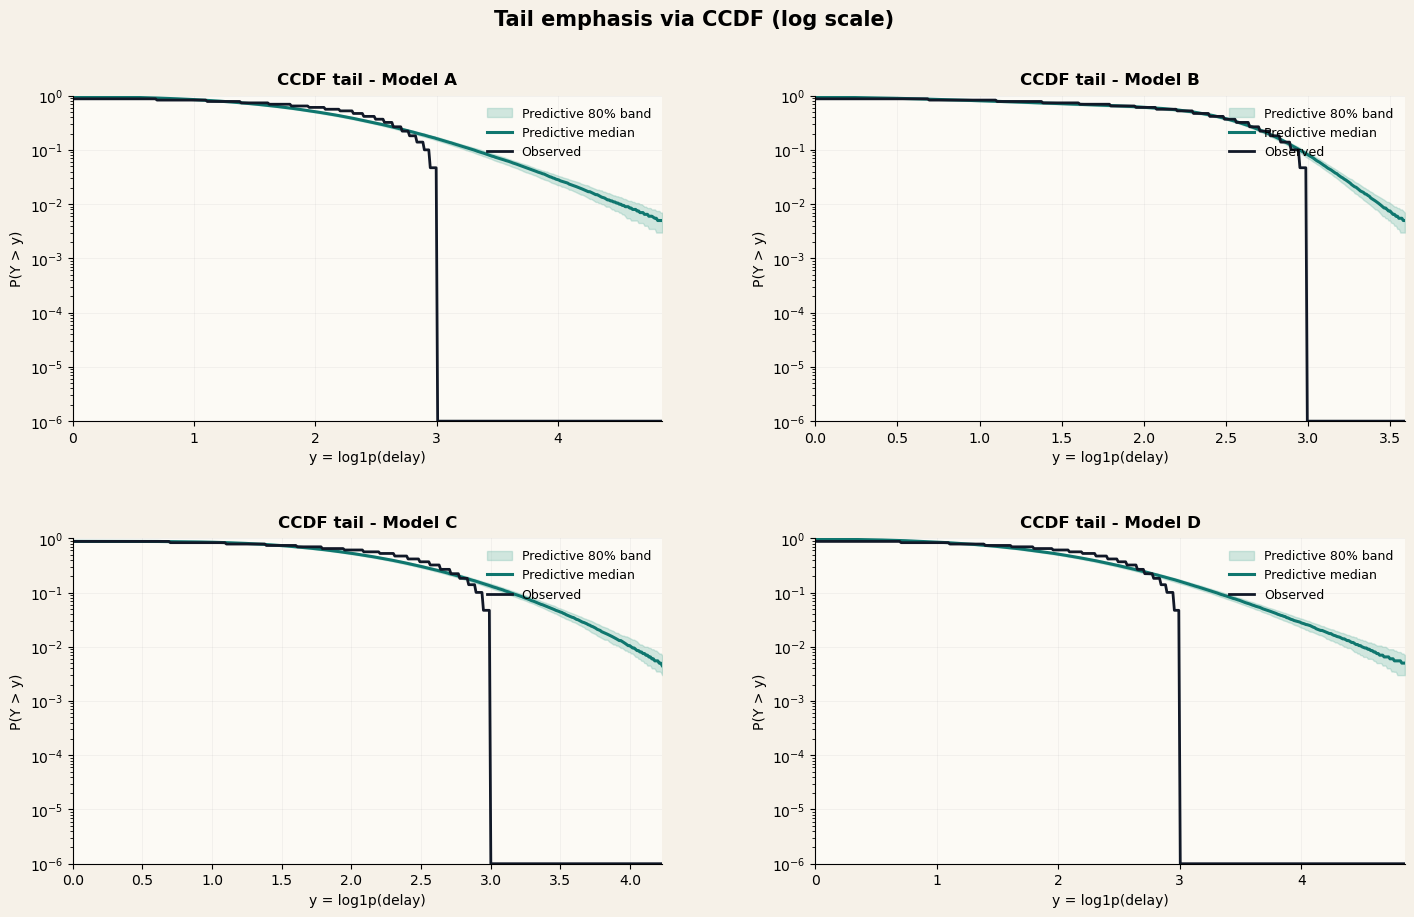

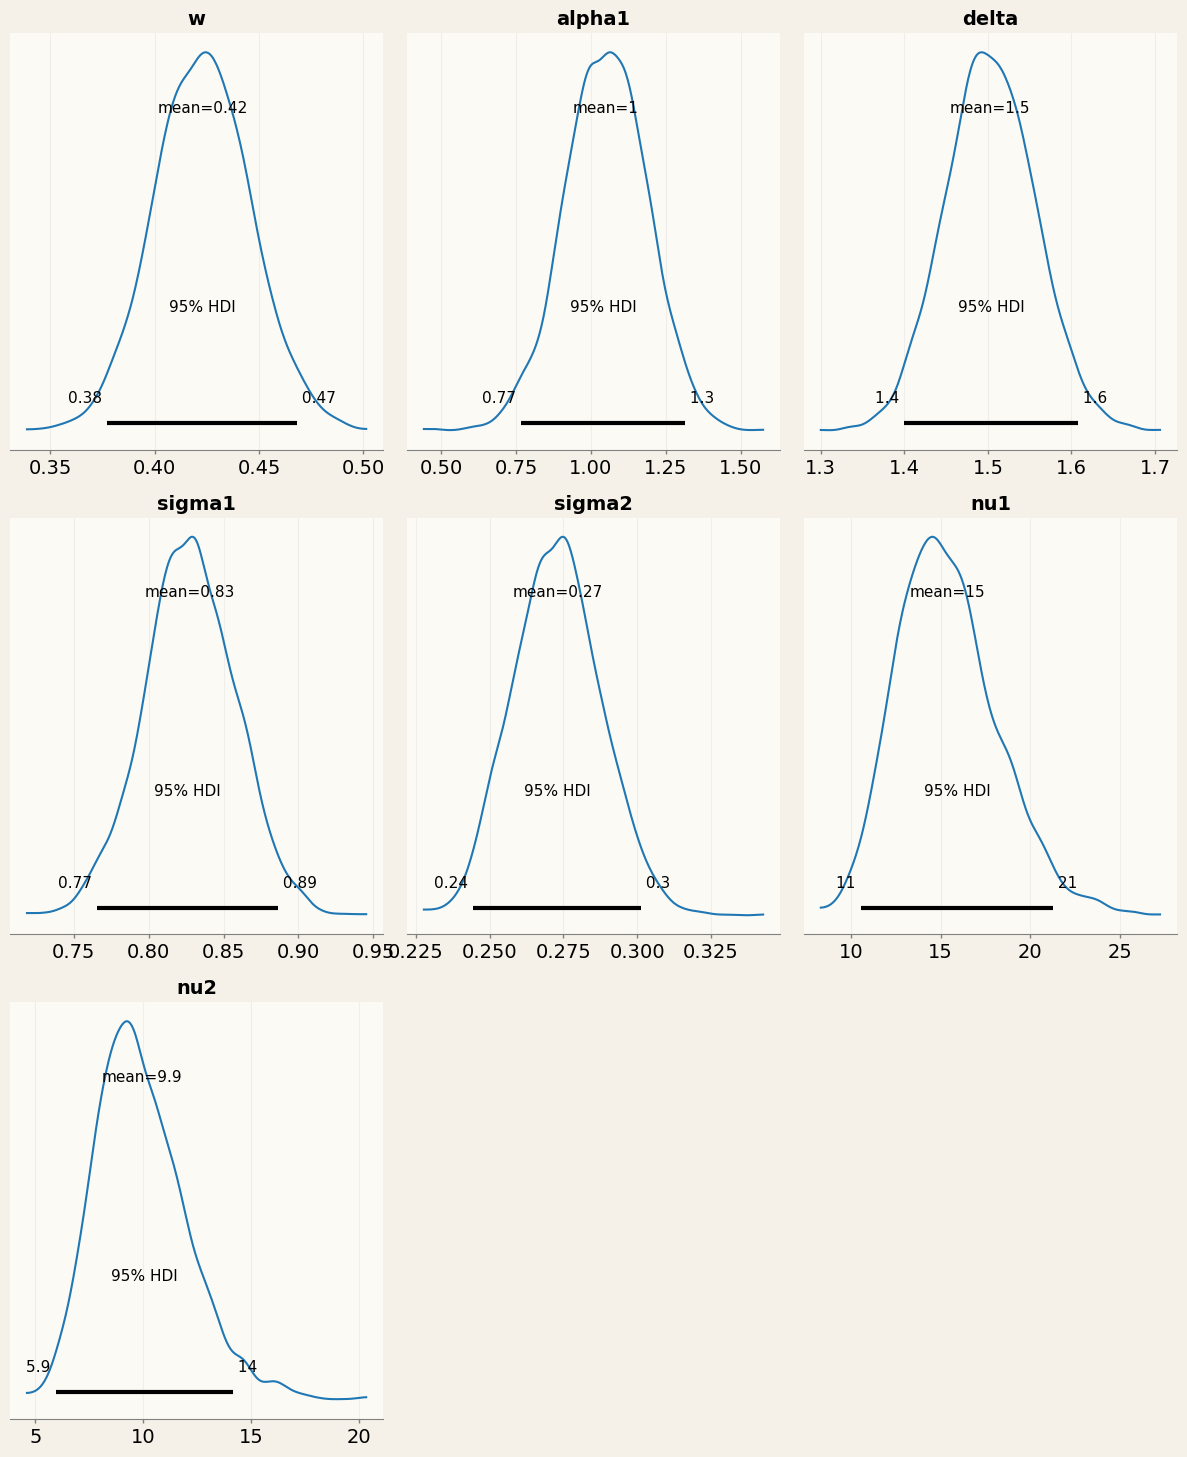

C:\Users\dell\AppData\Local\Temp\ipykernel_20976\4060972838.py:159: UserWarning: This figure includes Axes that are not compatible with tight_layout, so results might be incorrect.
  plt.tight_layout()


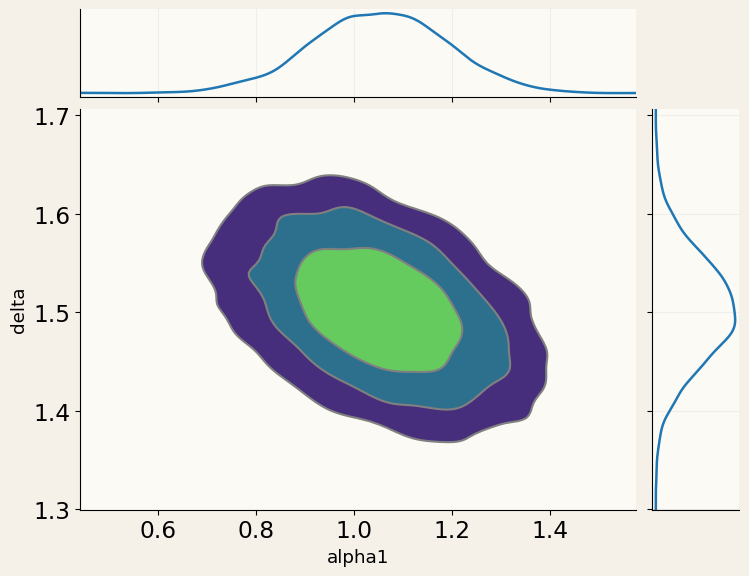

In [ ]:
candidate_order = [
    ("Model A", "idata_a"),
    ("Model B", "idata_b"),
    ("Model C", "idata_c"),
    ("Model D", "idata_d"),
    ("Single", "idata_single"),
    ("Mixture", "idata_mixture"),
    ("Zero-inflated", "idata_zi"),
]
model_map = {}
for label, var_name in candidate_order:
    obj = globals().get(var_name)
    if obj is not None and label not in model_map:
        model_map[label] = obj

if not model_map:
    raise RuntimeError("No idata_* objects found in the current session.")

loo_cache = {}
for label in model_map:
    key = {
        "Model A": "loo_a",
        "Model B": "loo_b",
        "Model C": "loo_c",
        "Model D": "loo_d",
        "Single": "loo_single",
        "Mixture": "loo_mix",
        "Zero-inflated": "loo_zi",
    }.get(label)
    if key and key in globals():
        loo_cache[label] = globals()[key]
    else:
        loo_cache[label] = az.loo(model_map[label], pointwise=True)

# A) Pareto-k histograms + compact summary (legacy parity with old notebook)
names = list(model_map.keys())
n_models = len(names)
n_cols = 2 if n_models > 1 else 1
n_rows = math.ceil(n_models / n_cols)
fig, axes = plt.subplots(n_rows, n_cols, figsize=(7.4 * n_cols, 4.4 * n_rows), squeeze=False)

pareto_rows = []
for i, name in enumerate(names):
    ax = axes[i // n_cols][i % n_cols]
    k_vals = np.asarray(loo_cache[name].pareto_k).ravel()
    ax.hist(k_vals, bins=40, color="#8b9fb5", alpha=0.85, edgecolor="white")
    ax.axvline(0.5, color="#0f766e", linestyle="--", linewidth=1.5)
    ax.axvline(0.7, color="#c67c2f", linestyle="--", linewidth=1.5)
    ax.axvline(1.0, color="#9f1239", linestyle="--", linewidth=1.5)
    ax.set_title(f"Pareto k - {name}", fontsize=12, fontweight="bold", pad=8)
    ax.set_xlabel("k", fontsize=10)
    ax.set_ylabel("count", fontsize=10)
    ax.tick_params(axis="both", labelsize=10)
    ax.set_facecolor("#fcfaf5")
    ax.grid(alpha=0.15, linewidth=0.6)
    pareto_rows.append(
        {
            "Model": name,
            "max_k": float(np.max(k_vals)),
            "share_k_gt_0.7": float(np.mean(k_vals > 0.7)),
        }
    )

for j in range(n_models, n_rows * n_cols):
    axes[j // n_cols][j % n_cols].axis("off")

fig.suptitle("Pareto-k distributions by model", fontsize=15, fontweight="bold", y=0.99)
fig.subplots_adjust(top=0.90, bottom=0.10, left=0.08, right=0.98, hspace=0.35, wspace=0.26)
plt.show()

pareto_hist_stats = pd.DataFrame(pareto_rows).set_index("Model").round(4)
display(pareto_hist_stats)

# B) Tail CCDF plot with predictive uncertainty (legacy CCDF functionality, model-wise)
def get_y_obs_rep(idata):
    if "y" in idata.observed_data:
        y_obs = np.asarray(idata.observed_data["y"]).ravel()
    else:
        obs_key = list(idata.observed_data.data_vars)[0]
        y_obs = np.asarray(idata.observed_data[obs_key]).ravel()
    rep_key = "y_rep" if "y_rep" in idata.posterior_predictive.data_vars else list(idata.posterior_predictive.data_vars)[0]
    y_rep = np.asarray(idata.posterior_predictive[rep_key]).reshape(-1, y_obs.size)
    return y_obs, y_rep


def ccdf_on_grid(samples, x_grid):
    s = np.sort(np.asarray(samples, dtype=float))
    n = s.size
    return 1.0 - np.searchsorted(s, x_grid, side="right") / max(n, 1)


fig, axes = plt.subplots(n_rows, n_cols, figsize=(7.4 * n_cols, 4.8 * n_rows), squeeze=False)
rng_local = np.random.default_rng(123)

for i, name in enumerate(names):
    ax = axes[i // n_cols][i % n_cols]
    y_obs, y_rep = get_y_obs_rep(model_map[name])
    y_obs = y_obs[np.isfinite(y_obs)]
    merged = np.concatenate([y_obs, y_rep.reshape(-1)])
    merged = merged[np.isfinite(merged)]
    x_max = float(np.quantile(merged, 0.995))
    x_grid = np.linspace(0.0, max(0.25, x_max), 400)

    obs_ccdf = ccdf_on_grid(y_obs, x_grid)

    draw_idx = rng_local.choice(y_rep.shape[0], size=min(250, y_rep.shape[0]), replace=False)
    ccdfs = []
    for d in draw_idx:
        vals = y_rep[d]
        vals = vals[np.isfinite(vals)]
        if vals.size > 2:
            ccdfs.append(ccdf_on_grid(vals, x_grid))
    if not ccdfs:
        ccdfs = [ccdf_on_grid(y_rep.reshape(-1), x_grid)]
    ccdfs = np.vstack(ccdfs)

    ccdf_med = np.median(ccdfs, axis=0)
    ccdf_lo = np.quantile(ccdfs, 0.10, axis=0)
    ccdf_hi = np.quantile(ccdfs, 0.90, axis=0)

    eps = 1e-6
    ax.fill_between(x_grid, np.maximum(ccdf_lo, eps), np.maximum(ccdf_hi, eps), color="#6bb8a9", alpha=0.30, label="Predictive 80% band")
    ax.plot(x_grid, np.maximum(ccdf_med, eps), color="#0f766e", linewidth=2.2, label="Predictive median")
    ax.plot(x_grid, np.maximum(obs_ccdf, eps), color="#111827", linewidth=2.0, label="Observed")
    ax.set_yscale("log")
    ax.set_xlim(0.0, max(0.25, x_max))
    ax.set_ylim(eps, 1.0)
    ax.set_title(f"CCDF tail - {name}", fontsize=12, fontweight="bold", pad=8)
    ax.set_xlabel("y = log1p(delay)", fontsize=10)
    ax.set_ylabel("P(Y > y)", fontsize=10)
    ax.tick_params(axis="both", labelsize=10)
    ax.legend(loc="upper right", fontsize=9)
    ax.set_facecolor("#fcfaf5")
    ax.grid(alpha=0.15, linewidth=0.6)

for j in range(n_models, n_rows * n_cols):
    axes[j // n_cols][j % n_cols].axis("off")

fig.suptitle("Tail emphasis via CCDF (log scale)", fontsize=15, fontweight="bold", y=0.99)
fig.subplots_adjust(top=0.90, bottom=0.10, left=0.08, right=0.98, hspace=0.36, wspace=0.26)
plt.show()

# C) Mixture posterior diagnostics (legacy plot_posterior/plot_pair adapted to current params)
idata_mix = globals().get("idata_b", globals().get("idata_mixture"))
if idata_mix is not None:
    available_vars = set(idata_mix.posterior.data_vars)
    posterior_vars = [v for v in ["w", "alpha1", "delta", "sigma1", "sigma2", "nu1", "nu2", "alpha_w"] if v in available_vars]
    if posterior_vars:
        az.plot_posterior(idata_mix, var_names=posterior_vars, figsize=(12, 2.1 * len(posterior_vars)))
        plt.tight_layout()
        plt.show()

    pair_options = [("alpha1", "delta"), ("sigma1", "sigma2"), ("nu1", "nu2")]
    chosen_pair = next((list(p) for p in pair_options if all(v in available_vars for v in p)), None)
    if chosen_pair:
        az.plot_pair(idata_mix, var_names=chosen_pair, kind="kde", marginals=True, figsize=(8.5, 6.5))
        plt.tight_layout()
        plt.show()
